# MaintenIA

## Predicción temprana de fallas en maquinaria industrial mediante un Árbol de Decisión

### Dataset

**AI4I 2020 Predictive Maintenance Dataset**

### Herramientas

* Google Colab
* Python
* Pandas
* NumPy
* Matplotlib
* Scikit-learn

### Modelo de Inteligencia Artificial

**Árbol de Decisión para clasificación**

### Variable objetivo

`Machine failure`

### Clases de predicción

* **0:** La máquina no presenta una falla.
* **1:** La máquina presenta una falla.

### Propósito del proyecto

Desarrollar un modelo de aprendizaje automático supervisado basado en un **Árbol de Decisión** que permita predecir de forma temprana posibles fallas en maquinaria industrial a partir de variables operativas registradas en el dataset AI4I 2020 Predictive Maintenance Dataset.

### Objetivo general

Diseñar, entrenar y evaluar un modelo de **Árbol de Decisión** capaz de clasificar el estado de una máquina industrial, determinando si existe o no una falla, con el fin de apoyar estrategias de mantenimiento predictivo.

### Comparación del proyecto

Los resultados obtenidos con este modelo serán comparados posteriormente con la versión desarrollada mediante una **Red Neuronal Artificial**, evaluando aspectos como precisión, interpretabilidad, facilidad de implementación, tiempo de entrenamiento y desempeño general.

### Estado del proyecto

En desarrollo.


# 1. Importación de librerías

En este bloque se importan todas las librerías necesarias para desarrollar el proyecto de mantenimiento predictivo mediante un Árbol de Decisión.

Cada una de estas librerías cumple una función específica, como la manipulación de datos, la visualización gráfica, la preparación del conjunto de datos, el entrenamiento del modelo, la evaluación de su rendimiento y el almacenamiento del modelo entrenado.

A diferencia de la versión basada en Redes Neuronales, este proyecto utiliza Scikit-learn como biblioteca principal para implementar el algoritmo Árbol de Decisión.

In [36]:
# ============================================================
# BLOQUE 1
# IMPORTACIÓN DE LIBRERÍAS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

# =====================================
# Librerías del sistema
# =====================================

import warnings
import random
import joblib

# =====================================
# Manipulación de datos
# =====================================

import numpy as np
import pandas as pd

# =====================================
# Visualización
# =====================================

import matplotlib.pyplot as plt

# =====================================
# División del dataset
# =====================================

from sklearn.model_selection import train_test_split

# =====================================
# Preprocesamiento
# =====================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# =====================================
# Modelo de Árbol de Decisión
# =====================================

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

# =====================================
# Métricas
# =====================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    classification_report
)

# =====================================
# Configuración general
# =====================================

warnings.filterwarnings("ignore")

SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)

# =====================================
# Mensaje de inicio
# =====================================

print("="*60)
print("PROYECTO MAINTENIA")
print("MODELO: ÁRBOL DE DECISIÓN")
print("="*60)

print("\nLibrerías cargadas correctamente.\n")

print("Versión de NumPy :", np.__version__)
print("Versión de Pandas:", pd.__version__)

print("\nBloque 1 ejecutado correctamente.")

PROYECTO MAINTENIA
MODELO: ÁRBOL DE DECISIÓN

Librerías cargadas correctamente.

Versión de NumPy : 2.0.2
Versión de Pandas: 2.2.2

Bloque 1 ejecutado correctamente.


# 2. Carga del Dataset

## Objetivo

En este bloque se realiza la carga del **AI4I 2020 Predictive Maintenance Dataset**, el conjunto de datos que será utilizado para desarrollar el modelo de mantenimiento predictivo mediante un **Árbol de Decisión**.

El dataset contiene información sobre las condiciones de operación de maquinaria industrial, incluyendo variables como la temperatura del aire, la temperatura del proceso, la velocidad de rotación, el torque, el desgaste de la herramienta y el estado de falla de la máquina.

La carga del archivo se realizará directamente desde el computador utilizando la herramienta de carga de archivos de Google Colab.

Para garantizar el correcto funcionamiento del proyecto, el archivo debe conservar su nombre original:

`ai4i2020.csv`

In [37]:
# ============================================================
# BLOQUE 2
# CARGA DEL DATASET
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

from google.colab import files

print("=" * 65)
print("CARGA DEL DATASET")
print("=" * 65)

print("\nSeleccione el archivo ai4i2020.csv desde su computador.\n")

archivos_cargados = files.upload()

CARGA DEL DATASET

Seleccione el archivo ai4i2020.csv desde su computador.



Saving ai4i2020.csv to ai4i2020 (3).csv


## 2.1 Lectura y Validación del Dataset

Una vez cargado el archivo en Google Colab, se procede a realizar su lectura mediante la biblioteca **Pandas**, verificando que el proceso de importación se haya completado correctamente.

El conjunto de datos será almacenado en un **DataFrame** denominado **dataset**, el cual constituirá la estructura principal utilizada durante las etapas de exploración, depuración, preparación de los datos, entrenamiento, evaluación y generación de predicciones del modelo de Árbol de Decisión.

Adicionalmente, se verificará el nombre del archivo recibido, el número de registros y la cantidad de columnas disponibles, garantizando que el dataset corresponda a la versión esperada del proyecto.

In [38]:
# ============================================================
# BLOQUE 2.1
# LECTURA Y VALIDACIÓN DEL DATASET
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

# Obtener el nombre del archivo cargado
NOMBRE_ARCHIVO = list(archivos_cargados.keys())[0]

# Leer el archivo
dataset = pd.read_csv(NOMBRE_ARCHIVO)

print("=" * 65)
print("DATASET CARGADO CORRECTAMENTE")
print("=" * 65)

print(f"\nNombre del archivo: {NOMBRE_ARCHIVO}")
print(f"Número de registros: {dataset.shape[0]}")
print(f"Número de columnas: {dataset.shape[1]}")

print("\nBloque 2 ejecutado correctamente.")

DATASET CARGADO CORRECTAMENTE

Nombre del archivo: ai4i2020 (3).csv
Número de registros: 10000
Número de columnas: 14

Bloque 2 ejecutado correctamente.


### Interpretación

El archivo fue cargado correctamente en el entorno de Google Colab y posteriormente leído mediante la biblioteca Pandas.

La validación permitió confirmar el nombre del archivo recibido, así como el número de registros y columnas disponibles, verificando que el conjunto de datos se encuentra listo para iniciar las etapas de exploración, depuración y preparación de la información.

Esta verificación constituye un paso fundamental dentro del flujo de trabajo de Ciencia de Datos, ya que garantiza que el modelo será entrenado utilizando un dataset correctamente cargado y estructurado.

2.2 Visualización Inicial del Dataset

Una vez cargado y validado el conjunto de datos, se realiza una inspección inicial para verificar que la información fue importada correctamente.

Se visualizarán los primeros registros del DataFrame con el fin de identificar la estructura del dataset, los nombres de las variables y el formato de los datos.

In [39]:
# ============================================================
# BLOQUE 2.2
# PRIMEROS REGISTROS DEL DATASET
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("PRIMEROS REGISTROS DEL DATASET")
print("=" * 65)

# Visualizar las primeras filas del DataFrame
display(dataset.head())

print("\nSe muestran los primeros cinco registros del dataset.")
print("Bloque 2.2 ejecutado correctamente.")

PRIMEROS REGISTROS DEL DATASET


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Se muestran los primeros cinco registros del dataset.
Bloque 2.2 ejecutado correctamente.


### Interpretación

La visualización de los primeros registros permitió verificar que el dataset fue cargado correctamente y que la información se encuentra organizada en un DataFrame.

Esta inspección inicial facilita la identificación de las variables disponibles, el tipo de datos almacenados en cada columna y la estructura general del conjunto de datos, constituyendo el primer paso del análisis exploratorio previo al proceso de depuración y entrenamiento del modelo de Árbol de Decisión.

# 3. Exploración y Diagnóstico Inicial del Dataset

## Objetivo

En este bloque se realiza una exploración inicial del conjunto de datos con el propósito de comprender su estructura, verificar la calidad de la información y detectar posibles inconsistencias antes de iniciar el proceso de depuración.

Durante esta etapa se analizarán aspectos como las dimensiones del dataset, los nombres de las variables, los tipos de datos almacenados y la información general del DataFrame.

Este análisis constituye una buena práctica en proyectos de Ciencia de Datos e Inteligencia Artificial, ya que permite conocer el estado del conjunto de datos antes de aplicar cualquier técnica de preprocesamiento o entrenamiento del modelo.

## 3.1 Dimensiones del Dataset

El primer análisis consiste en identificar el número de registros y columnas que conforman el conjunto de datos.

Conocer estas dimensiones permite confirmar que el dataset fue cargado completamente y coincide con la estructura esperada del AI4I 2020 Predictive Maintenance Dataset.

In [40]:
# ============================================================
# BLOQUE 3.1
# DIMENSIONES DEL DATASET
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("DIMENSIONES DEL DATASET")
print("=" * 65)

filas, columnas = dataset.shape

print(f"Número de registros : {filas}")
print(f"Número de columnas  : {columnas}")

DIMENSIONES DEL DATASET
Número de registros : 10000
Número de columnas  : 14


### Interpretación

La función **shape** devuelve las dimensiones del conjunto de datos, indicando el número total de registros (filas) y variables (columnas).

Para el dataset original **AI4I 2020 Predictive Maintenance Dataset** se espera encontrar aproximadamente **10.000 registros** y **14 columnas**. Estos valores confirman que la carga del archivo se realizó correctamente y que la estructura del conjunto de datos corresponde a la versión oficial utilizada en este proyecto.

## 3.2 Identificación de las Variables

### Objetivo

En este apartado se identifican las variables que conforman el conjunto de datos y se analiza el propósito de cada una dentro del proceso de mantenimiento predictivo.

Conocer el significado de cada variable permite comprender la información disponible, seleccionar las características más relevantes para el entrenamiento del modelo y detectar aquellas que podrían generar redundancia o fuga de información durante el proceso de aprendizaje.

In [41]:
# ============================================================
# BLOQUE 3.2
# IDENTIFICACIÓN DE LAS VARIABLES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("VARIABLES DEL DATASET")
print("=" * 65)

for indice, columna in enumerate(dataset.columns, start=1):
    print(f"{indice:2d}. {columna}")

VARIABLES DEL DATASET
 1. UDI
 2. Product ID
 3. Type
 4. Air temperature [K]
 5. Process temperature [K]
 6. Rotational speed [rpm]
 7. Torque [Nm]
 8. Tool wear [min]
 9. Machine failure
10. TWF
11. HDF
12. PWF
13. OSF
14. RNF


### Interpretación

El dataset está conformado por catorce variables que describen las condiciones de funcionamiento de la maquinaria industrial.

Estas variables incluyen identificadores, características operativas y diferentes tipos de fallas registradas durante la operación de la máquina.

La variable **Machine failure** representa la variable objetivo del proyecto y será utilizada para entrenar el modelo de clasificación mediante un Árbol de Decisión.

## 3.3 Descripción de las Variables

La siguiente tabla presenta una descripción de cada una de las variables contenidas en el **AI4I 2020 Predictive Maintenance Dataset**.

Este análisis permite comprender el significado de cada atributo antes de iniciar el proceso de limpieza, selección de variables y entrenamiento del modelo.

In [42]:
# ============================================================
# BLOQUE 3.3
# DESCRIPCIÓN DE LAS VARIABLES
# ============================================================

descripcion_variables = pd.DataFrame({

    "Variable": [
        "UDI",
        "Product ID",
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ],

    "Descripción": [

        "Identificador único del registro.",

        "Código de identificación del producto.",

        "Tipo de producto (L, M o H).",

        "Temperatura del aire medida en Kelvin.",

        "Temperatura del proceso medida en Kelvin.",

        "Velocidad de rotación del eje en revoluciones por minuto.",

        "Torque aplicado durante la operación.",

        "Tiempo acumulado de desgaste de la herramienta.",

        "Indica si la máquina presentó una falla general.",

        "Falla por desgaste de la herramienta.",

        "Falla por disipación de calor.",

        "Falla relacionada con la potencia.",

        "Falla por sobrecarga.",

        "Falla aleatoria."
    ]
})

display(descripcion_variables)

,Variable,Descripción
0,UDI,Identificador único del registro.
1,Product ID,Código de identificación del producto.
2,Type,"Tipo de producto (L, M o H)."
3,Air temperature [K],Temperatura del aire medida en Kelvin.
4,Process temperature [K],Temperatura del proceso medida en Kelvin.
5,Rotational speed [rpm],Velocidad de rotación del eje en revoluciones ...
6,Torque [Nm],Torque aplicado durante la operación.
7,Tool wear [min],Tiempo acumulado de desgaste de la herramienta.
8,Machine failure,Indica si la máquina presentó una falla general.
9,TWF,Falla por desgaste de la herramienta.


### Interpretación

La descripción de las variables facilita la comprensión del conjunto de datos y permite identificar el papel que desempeña cada atributo dentro del proceso de mantenimiento predictivo.

Durante las siguientes etapas del proyecto se evaluará cuáles variables serán utilizadas como características de entrada y cuáles deberán excluirse para evitar problemas de redundancia o fuga de información.

## 3.4 Estadísticas Descriptivas

### Objetivo

En este apartado se realiza un análisis estadístico descriptivo de las variables numéricas presentes en el dataset.

Las estadísticas descriptivas permiten conocer el comportamiento general de los datos mediante indicadores como la cantidad de registros, el promedio, la desviación estándar, los valores mínimos, máximos y los diferentes cuartiles.

Este análisis facilita la identificación de posibles valores atípicos, rangos de operación y la distribución general de cada variable antes de iniciar la etapa de depuración y entrenamiento del modelo.

In [43]:
# ============================================================
# BLOQUE 3.4
# ESTADÍSTICAS DESCRIPTIVAS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 65)

display(dataset.describe())

ESTADÍSTICAS DESCRIPTIVAS


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Interpretación

La función **describe()** genera un resumen estadístico de todas las variables numéricas del dataset, proporcionando información relevante sobre la distribución y el comportamiento de los datos antes del entrenamiento del modelo.

Entre los indicadores más importantes se encuentran:

- **count:** cantidad de registros disponibles para cada variable.
- **mean:** valor promedio de los datos.
- **std:** desviación estándar, que indica el grado de dispersión de los valores respecto al promedio.
- **min:** valor mínimo registrado.
- **25% (Primer cuartil - Q1):** indica que el 25 % de las observaciones presentan valores iguales o inferiores a este punto.
- **50% (Segundo cuartil o mediana - Q2):** corresponde al valor central de la distribución, dividiendo el conjunto de datos en dos partes iguales.
- **75% (Tercer cuartil - Q3):** indica que el 75 % de las observaciones presentan valores iguales o inferiores a este punto.
- **max:** valor máximo registrado.

El análisis de los cuartiles permite comprender la distribución de los datos, evaluar su dispersión e identificar posibles valores atípicos (outliers), los cuales serán analizados con mayor detalle durante la etapa de depuración del dataset.

En conjunto, estas estadísticas descriptivas proporcionan una visión general de la calidad de los datos y constituyen una base fundamental para el proceso de preparación, entrenamiento y evaluación del modelo de Árbol de Decisión.

## 3.4.1 Interpretación de los Cuartiles

Los cuartiles son medidas estadísticas que dividen un conjunto de datos ordenado en cuatro partes iguales.

Su análisis permite comprender cómo se distribuyen los valores de cada variable y facilita la identificación de posibles valores atípicos antes del entrenamiento del modelo.

En este apartado se calcularán los cuartiles de las principales variables numéricas del dataset para conocer su comportamiento y dispersión.

In [44]:
# ============================================================
# BLOQUE 3.4.1
# INTERPRETACIÓN DE LOS CUARTILES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("INTERPRETACIÓN DE LOS CUARTILES")
print("=" * 70)

variables_numericas = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

cuartiles = dataset[variables_numericas].quantile([0.25, 0.50, 0.75])

display(cuartiles)

INTERPRETACIÓN DE LOS CUARTILES


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0.25,298.3,308.8,1423.0,33.2,53.0
0.50,300.1,310.1,1503.0,40.1,108.0
0.75,301.5,311.1,1612.0,46.8,162.0


### Interpretación

Los cuartiles permiten dividir la distribución de cada variable numérica en cuatro partes iguales.

Su interpretación es la siguiente:

- **Primer cuartil (Q1 - 25 %):** indica que el 25 % de las observaciones presentan valores iguales o inferiores a este punto.
- **Segundo cuartil (Q2 - 50 %):** corresponde a la mediana y divide el conjunto de datos en dos partes iguales.
- **Tercer cuartil (Q3 - 75 %):** indica que el 75 % de las observaciones presentan valores iguales o inferiores a este punto.

El análisis de los cuartiles permite comprender la distribución de las variables y constituye una referencia fundamental para la identificación de posibles valores atípicos mediante diagramas de caja (Boxplots).

En el contexto del mantenimiento predictivo, esta información facilita la detección de comportamientos inusuales que podrían influir en el entrenamiento y desempeño del modelo de Árbol de Decisión.

## 3.5 Identificación de Valores Nulos

### Objetivo

Antes de entrenar cualquier modelo de Inteligencia Artificial es indispensable verificar la existencia de valores faltantes.

Los valores nulos pueden afectar el proceso de entrenamiento y disminuir el rendimiento del modelo, por lo que su identificación constituye una etapa fundamental dentro del preprocesamiento de datos.

### Conclusión

El análisis de los cuartiles proporciona una visión más detallada de la distribución de las variables numéricas del conjunto de datos.

Esta información servirá como base para el siguiente apartado, donde se emplearán diagramas de caja (Boxplots) para identificar visualmente la presencia de posibles valores atípicos y evaluar si requieren algún tratamiento durante la etapa de preparación de los datos.

## 3.4.2 Identificación de Valores Atípicos (Boxplots)

### Objetivo

En este apartado se utilizan diagramas de caja (Boxplots) para identificar visualmente la presencia de posibles valores atípicos en las principales variables numéricas del conjunto de datos.

Los valores atípicos corresponden a observaciones que se encuentran significativamente alejadas del comportamiento general de los datos. En algunos problemas pueden representar errores de captura; sin embargo, en aplicaciones de mantenimiento predictivo también pueden corresponder a condiciones reales de operación o eventos previos a una falla.

Por esta razón, los valores atípicos serán analizados cuidadosamente antes de decidir si deben conservarse o tratarse durante la etapa de preparación del dataset.

IDENTIFICACIÓN DE VALORES ATÍPICOS


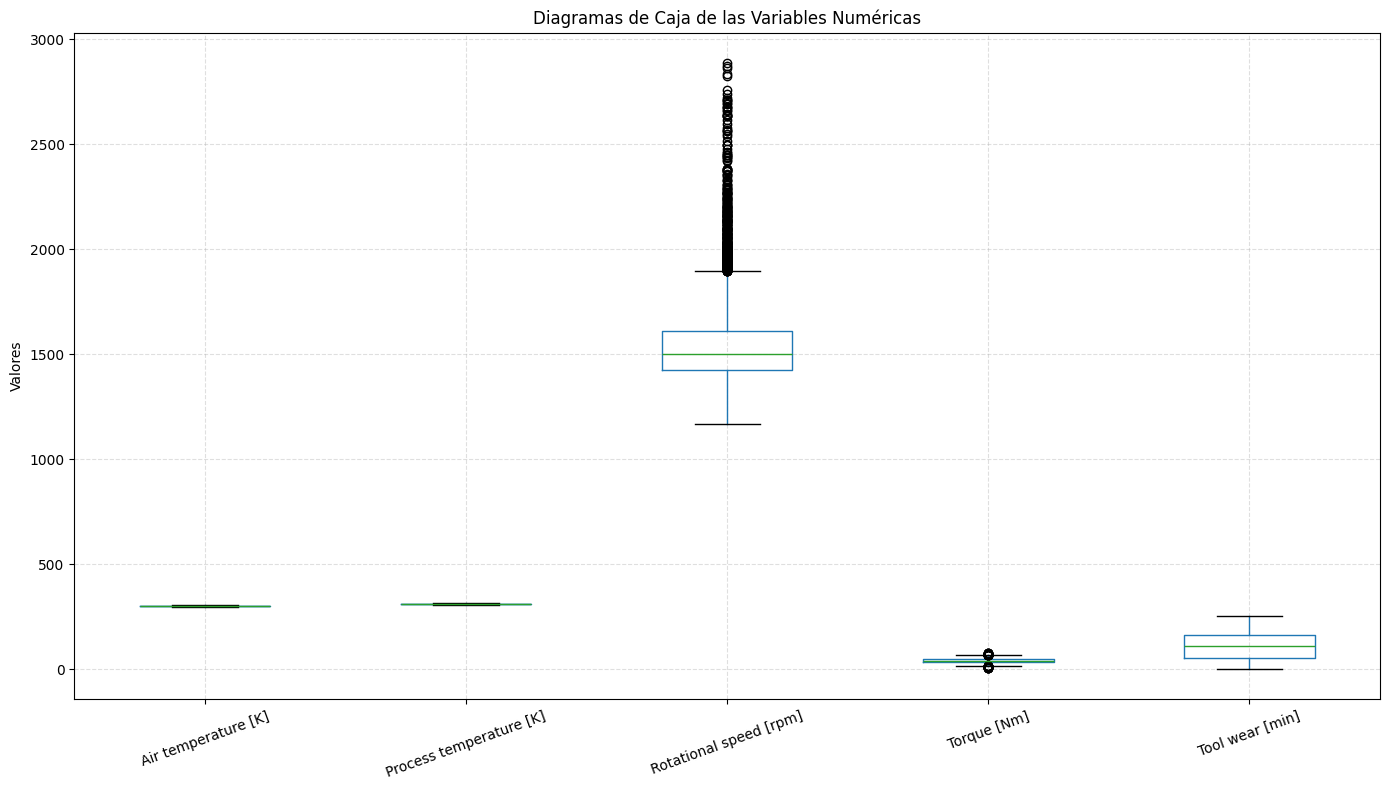

In [45]:
# ============================================================
# BLOQUE 3.4.2
# IDENTIFICACIÓN DE VALORES ATÍPICOS (BOXPLOTS)
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("IDENTIFICACIÓN DE VALORES ATÍPICOS")
print("=" * 70)

variables_numericas = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

plt.figure(figsize=(14,8))

dataset[variables_numericas].boxplot()

plt.title("Diagramas de Caja de las Variables Numéricas")

plt.ylabel("Valores")

plt.xticks(rotation=20)

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretación

Los diagramas de caja permiten visualizar la distribución de cada variable numérica mediante cinco elementos principales:

- Valor mínimo.
- Primer cuartil (Q1).
- Mediana (Q2).
- Tercer cuartil (Q3).
- Valor máximo.

Además, los puntos que aparecen por fuera de los límites del diagrama representan posibles valores atípicos (outliers).

La presencia de valores atípicos no implica necesariamente que deban eliminarse. En proyectos de mantenimiento predictivo estos registros pueden corresponder a condiciones reales de operación, sobrecargas, desgastes anormales o eventos asociados a fallas de la maquinaria.

In [46]:
# ============================================================
# RESUMEN DE POSIBLES VALORES ATÍPICOS
# ============================================================

print("=" * 70)
print("RESUMEN DE POSIBLES VALORES ATÍPICOS")
print("=" * 70)

for variable in variables_numericas:

    Q1 = dataset[variable].quantile(0.25)
    Q3 = dataset[variable].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad = dataset[
        (dataset[variable] < limite_inferior) |
        (dataset[variable] > limite_superior)
    ].shape[0]

    print(f"{variable}: {cantidad} posibles valores atípicos")

RESUMEN DE POSIBLES VALORES ATÍPICOS
Air temperature [K]: 0 posibles valores atípicos
Process temperature [K]: 0 posibles valores atípicos
Rotational speed [rpm]: 418 posibles valores atípicos
Torque [Nm]: 69 posibles valores atípicos
Tool wear [min]: 0 posibles valores atípicos


### Interpretación

El análisis cuantitativo complementa la inspección visual realizada mediante los diagramas de caja.

Para cada variable se calcula el rango intercuartílico (IQR), el cual permite estimar los límites utilizados para identificar posibles valores atípicos.

La cantidad de registros detectados no implica que estos correspondan a errores de medición. En el contexto del mantenimiento predictivo, muchos de estos valores pueden representar condiciones extremas de operación que aportan información valiosa para el entrenamiento del modelo.

### Conclusión

El análisis realizado permitió identificar la presencia de posibles valores atípicos en algunas variables del conjunto de datos.

Debido a la naturaleza del problema de mantenimiento predictivo, estos registros no serán eliminados automáticamente. En muchos casos representan comportamientos reales de la maquinaria y pueden contener información relevante para la predicción de fallas.

La decisión final sobre su tratamiento será tomada durante la etapa de preparación del dataset, considerando tanto el comportamiento estadístico de los datos como el impacto que puedan tener sobre el desempeño del modelo de Árbol de Decisión.

In [47]:
# ============================================================
# BLOQUE 3.5
# VALORES NULOS
# ============================================================

print("=" * 65)
print("VALORES NULOS")
print("=" * 65)

valores_nulos = dataset.isnull().sum()

display(valores_nulos)

VALORES NULOS


,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


### Interpretación

La función **isnull().sum()** contabiliza la cantidad de valores faltantes presentes en cada una de las variables del conjunto de datos.

En el AI4I 2020 Predictive Maintenance Dataset se espera que todas las variables presenten cero valores nulos, indicando que el conjunto de datos está completo y puede utilizarse sin necesidad de aplicar técnicas de imputación.

In [48]:
# ============================================================
# RESUMEN GENERAL DE VALORES NULOS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

total_nulos = valores_nulos.sum()

print("=" * 65)
print("RESUMEN GENERAL DE VALORES NULOS")
print("=" * 65)

print(f"Total de valores nulos encontrados: {total_nulos}")

if total_nulos == 0:
    print("\n✅ El dataset no presenta valores nulos.")
else:
    print("\n⚠️ Se encontraron valores nulos y deberán tratarse antes del entrenamiento del modelo.")

RESUMEN GENERAL DE VALORES NULOS
Total de valores nulos encontrados: 0

✅ El dataset no presenta valores nulos.


### Conclusión

El análisis realizado confirma si el conjunto de datos contiene valores faltantes.

En caso de no existir valores nulos, se garantiza que todas las observaciones están completas, permitiendo continuar con el proceso de preparación de los datos sin aplicar técnicas de imputación.

Esta verificación constituye una buena práctica dentro del proceso de preprocesamiento de datos para modelos de aprendizaje automático.

## 3.6 Identificación de Registros Duplicados

### Objetivo

En este apartado se verifica si existen registros completamente duplicados dentro del conjunto de datos.

La presencia de registros duplicados puede afectar el proceso de entrenamiento del modelo, generando sesgos en el aprendizaje y alterando la evaluación del rendimiento. Por esta razón, su identificación constituye una etapa importante del proceso de preprocesamiento de datos.

In [49]:
# ============================================================
# BLOQUE 3.6
# IDENTIFICACIÓN DE REGISTROS DUPLICADOS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("REGISTROS DUPLICADOS")
print("=" * 65)

duplicados = dataset.duplicated().sum()

print(f"Total de registros duplicados encontrados: {duplicados}")

REGISTROS DUPLICADOS
Total de registros duplicados encontrados: 0


### Interpretación

La función **duplicated().sum()** permite identificar la cantidad de registros completamente repetidos dentro del DataFrame.

Los registros duplicados pueden ocasionar que el modelo aprenda varias veces la misma información, afectando la capacidad de generalización durante el entrenamiento.

In [50]:
# ============================================================
# RESUMEN GENERAL DE REGISTROS DUPLICADOS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("RESUMEN GENERAL DE REGISTROS DUPLICADOS")
print("=" * 65)

if duplicados == 0:
    print("✅ El dataset no presenta registros duplicados.")
else:
    print(f"⚠️ Se encontraron {duplicados} registros duplicados.")
    print("Se recomienda eliminarlos antes del entrenamiento del modelo.")

RESUMEN GENERAL DE REGISTROS DUPLICADOS
✅ El dataset no presenta registros duplicados.


### Conclusión

La verificación realizada permite confirmar si existen registros duplicados dentro del conjunto de datos.

En el caso del **AI4I 2020 Predictive Maintenance Dataset**, se espera que no existan registros completamente repetidos. Esto garantiza que cada observación corresponde a un evento independiente de operación de la maquinaria y permite continuar con confianza hacia las siguientes etapas del proyecto.

## 3.7 Análisis de la Variable Objetivo

### Objetivo

En este apartado se analiza la distribución de la variable objetivo **Machine failure**, la cual representa el estado final de la máquina durante su operación.

Este análisis permite conocer la cantidad de registros correspondientes a máquinas que presentan una falla y aquellas que operan normalmente.

La distribución de la variable objetivo es un aspecto fundamental en proyectos de aprendizaje automático, ya que un conjunto de datos desbalanceado puede influir en el proceso de entrenamiento y en la evaluación del modelo de clasificación.

In [51]:
# ============================================================
# BLOQUE 3.7
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 65)

distribucion = dataset["Machine failure"].value_counts().sort_index()

display(distribucion)


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO


,count
Machine failure,
0,9661
1,339


### Interpretación

La función **value_counts()** contabiliza la cantidad de registros pertenecientes a cada clase de la variable objetivo.

Los valores representan:

- **0:** La máquina no presentó una falla.
- **1:** La máquina presentó una falla.

Esta información permite conocer la distribución inicial de las clases antes del entrenamiento del modelo.

## 3.7.1 Resumen de la Distribución de la Variable Objetivo

En este apartado se contabiliza la cantidad de registros pertenecientes a cada clase de la variable objetivo **Machine failure**.

Este análisis permite conocer cuántas máquinas presentan una falla y cuántas operan normalmente antes del entrenamiento del modelo.

In [52]:
# ============================================================
# BLOQUE 3.7.1
# RESUMEN DE LA DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("RESUMEN DE LA DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 70)

# Cantidad de registros
cantidad = dataset["Machine failure"].value_counts().sort_index()

# Porcentaje
porcentaje = (
    dataset["Machine failure"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Construcción de la tabla resumen
resumen_clases = pd.DataFrame({

    "Clase": cantidad.index,
    "Estado": ["Sin falla", "Con falla"],
    "Cantidad": cantidad.values,
    "Porcentaje (%)": porcentaje.values

})

display(resumen_clases)

RESUMEN DE LA DISTRIBUCIÓN DE LA VARIABLE OBJETIVO


,Clase,Estado,Cantidad,Porcentaje (%)
0,0,Sin falla,9661,96.61
1,1,Con falla,339,3.39


### Interpretación

La tabla resume la distribución de la variable objetivo **Machine failure**, mostrando tanto la cantidad de registros como el porcentaje correspondiente a cada clase.

Se observa que la mayor parte de las observaciones corresponden a máquinas que no presentan fallas, mientras que la proporción de máquinas con fallas es considerablemente menor.

Este comportamiento indica que el conjunto de datos presenta un desbalance entre sus clases, situación frecuente en aplicaciones de mantenimiento predictivo. Por ello, durante la evaluación del modelo será necesario considerar métricas adicionales a la exactitud (Accuracy), como Precision, Recall, F1-Score y ROC-AUC.

## 3.7.2 Representación Gráfica mediante Barras

En este apartado se representa gráficamente la distribución de la variable objetivo **Machine failure** mediante una gráfica de barras.

La visualización permite comparar de forma directa la cantidad de registros correspondientes a máquinas sin falla y máquinas con falla. También facilita la identificación del desbalance existente entre las clases antes del entrenamiento del modelo de Árbol de Decisión.

REPRESENTACIÓN GRÁFICA MEDIANTE BARRAS


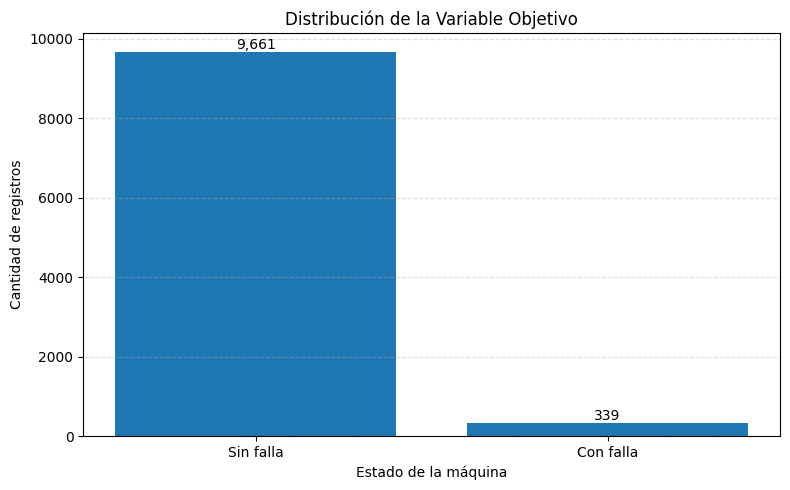

In [53]:
# ============================================================
# BLOQUE 3.7.2
# REPRESENTACIÓN GRÁFICA MEDIANTE BARRAS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("REPRESENTACIÓN GRÁFICA MEDIANTE BARRAS")
print("=" * 65)

# Obtener la cantidad de registros de cada clase
conteo_clases = (
    dataset["Machine failure"]
    .value_counts()
    .sort_index()
)

# Crear las etiquetas de las clases
etiquetas = ["Sin falla", "Con falla"]

# Crear la gráfica
plt.figure(figsize=(8, 5))

barras = plt.bar(
    etiquetas,
    conteo_clases.values
)

# Agregar el valor numérico encima de cada barra
for barra, cantidad_clase in zip(barras, conteo_clases.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{cantidad_clase:,}",
        ha="center",
        va="bottom"
    )

# Configuración de la gráfica
plt.title("Distribución de la Variable Objetivo")
plt.xlabel("Estado de la máquina")
plt.ylabel("Cantidad de registros")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

### Interpretación

La gráfica de barras evidencia una diferencia considerable entre las dos clases de la variable objetivo.

La mayoría de los registros corresponde a máquinas que no presentan fallas, mientras que las observaciones asociadas a fallas representan una proporción mucho menor del conjunto de datos.

Este resultado confirma visualmente que la variable objetivo se encuentra desbalanceada. Por esta razón, la evaluación del modelo no deberá basarse únicamente en la exactitud (**Accuracy**), ya que un modelo podría obtener un valor elevado al favorecer principalmente la clase mayoritaria.

En etapas posteriores se utilizarán métricas como **Precision**, **Recall**, **F1-Score** y **ROC-AUC** para evaluar con mayor precisión la capacidad del modelo para identificar las fallas.

## 3.7.3 Representación Gráfica mediante Gráfico Circular

REPRESENTACIÓN GRÁFICA MEDIANTE GRÁFICO CIRCULAR


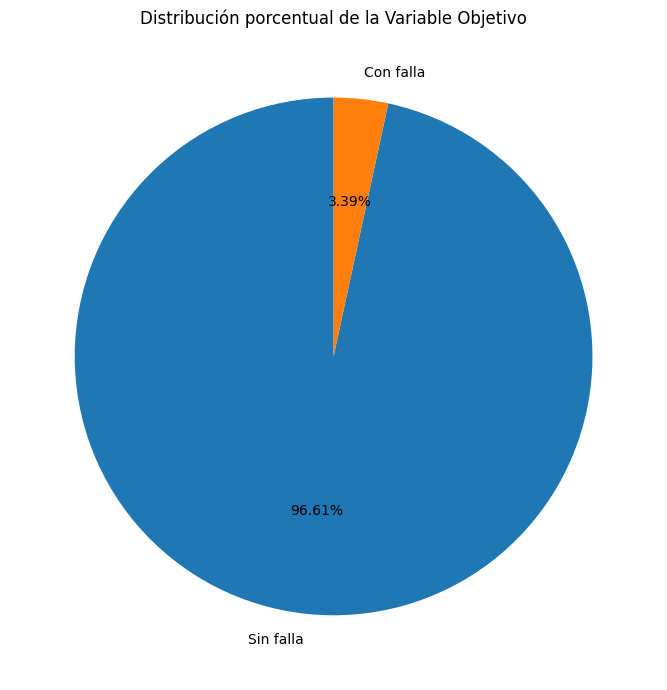

In [54]:
# ============================================================
# BLOQUE 3.7.3
# REPRESENTACIÓN GRÁFICA MEDIANTE GRÁFICO CIRCULAR
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("REPRESENTACIÓN GRÁFICA MEDIANTE GRÁFICO CIRCULAR")
print("=" * 65)

# Cantidad de registros por clase
conteo_clases = (
    dataset["Machine failure"]
    .value_counts()
    .sort_index()
)

# Etiquetas
etiquetas = [
    "Sin falla",
    "Con falla"
]

# Crear gráfico circular
plt.figure(figsize=(7,7))

plt.pie(
    conteo_clases.values,
    labels=etiquetas,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Distribución porcentual de la Variable Objetivo")

plt.tight_layout()

plt.show()

### Interpretación

El gráfico circular muestra la proporción que representa cada clase dentro del conjunto de datos.

Se observa que la mayor parte de los registros corresponde a máquinas que operan normalmente, mientras que únicamente un pequeño porcentaje pertenece a máquinas que presentan una falla.

Esta representación gráfica confirma el desbalance de la variable objetivo, característica habitual en problemas de mantenimiento predictivo, donde los eventos de falla ocurren con menor frecuencia que el funcionamiento normal de los equipos.

### Conclusión

El análisis de la variable objetivo permitió identificar que el conjunto de datos presenta una distribución desbalanceada entre las clases **"Sin falla"** y **"Con falla"**.

Este comportamiento es consistente con escenarios reales de mantenimiento predictivo, donde la mayoría de las máquinas operan sin presentar fallas y solo una pequeña proporción experimenta eventos de fallo.

La información obtenida en este apartado servirá como base para interpretar correctamente el desempeño del modelo durante las etapas de entrenamiento y evaluación, empleando métricas apropiadas para conjuntos de datos desbalanceados.

## 3.8 Análisis de Correlación entre Variables

### Objetivo

En este apartado se analiza la relación existente entre las variables numéricas del conjunto de datos mediante una matriz de correlación.

El análisis de correlación permite identificar el grado de asociación lineal entre las variables, facilitando la detección de relaciones fuertes, posibles redundancias y variables que podrían influir directamente sobre la variable objetivo.

Los resultados obtenidos servirán como apoyo para justificar técnicamente las decisiones que se tomarán durante la etapa de depuración y selección de variables.

In [55]:
# ============================================================
# BLOQUE 3.8
# ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES")
print("=" * 70)

print("\nSe analizará la relación existente entre las variables numéricas")
print("del conjunto de datos mediante una matriz de correlación y")
print("su representación gráfica (Heatmap).\n")

ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES

Se analizará la relación existente entre las variables numéricas
del conjunto de datos mediante una matriz de correlación y
su representación gráfica (Heatmap).



### Interpretación

El análisis de correlación constituye una etapa importante dentro del proceso de exploración de datos, ya que permite identificar el grado de relación existente entre las variables numéricas del conjunto de datos.

Comprender estas relaciones facilita la identificación de variables relevantes para la predicción de fallas, posibles redundancias y asociaciones que podrían influir en el desempeño del modelo.

Los resultados obtenidos servirán como apoyo para la selección de variables durante la etapa de preparación del dataset.

## 3.8.1 Matriz de Correlación

La matriz de correlación permite analizar el grado de relación lineal existente entre las variables numéricas del conjunto de datos.

Los coeficientes de correlación toman valores entre **-1** y **1**:

- **1:** Correlación positiva perfecta.
- **0:** No existe correlación lineal.
- **-1:** Correlación negativa perfecta.

Este análisis constituye una herramienta importante para identificar relaciones entre variables y apoyar la selección de características que serán utilizadas durante el entrenamiento del modelo de Árbol de Decisión.

In [56]:
# ============================================================
# BLOQUE 3.8.1
# MATRIZ DE CORRELACIÓN
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("MATRIZ DE CORRELACIÓN")
print("=" * 70)

# Seleccionar únicamente variables numéricas
correlacion = dataset.select_dtypes(include=["number"]).corr()

display(correlacion.round(3))

MATRIZ DE CORRELACIÓN


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000,0.117,0.324,-0.007,0.003,-0.011,-0.023,0.009,-0.022,-0.024,-0.001,-0.006
Air temperature [K],0.117,1.000,0.876,0.023,-0.014,0.014,0.083,0.010,0.138,0.003,0.002,0.018
Process temperature [K],0.324,0.876,1.000,0.019,-0.014,0.013,0.036,0.007,0.057,-0.003,0.005,0.022
Rotational speed [rpm],-0.007,0.023,0.019,1.000,-0.875,0.000,-0.044,0.010,-0.121,0.123,-0.105,-0.013
Torque [Nm],0.003,-0.014,-0.014,-0.875,1.000,-0.003,0.191,-0.015,0.143,0.084,0.183,0.016
Tool wear [min],-0.011,0.014,0.013,0.000,-0.003,1.000,0.105,0.116,-0.001,-0.009,0.156,0.011
Machine failure,-0.023,0.083,0.036,-0.044,0.191,0.105,1.000,0.363,0.576,0.523,0.531,0.005
TWF,0.009,0.010,0.007,0.010,-0.015,0.116,0.363,1.000,-0.007,0.009,0.038,0.031
HDF,-0.022,0.138,0.057,-0.121,0.143,-0.001,0.576,-0.007,1.000,0.018,0.046,-0.005
PWF,-0.024,0.003,-0.003,0.123,0.084,-0.009,0.523,0.009,0.018,1.000,0.116,-0.004


### Interpretación

La matriz de correlación muestra el grado de relación existente entre todas las variables numéricas del dataset.

Los valores cercanos a **1** indican una relación positiva fuerte, mientras que los valores próximos a **-1** representan una relación negativa fuerte. Por el contrario, valores cercanos a **0** indican poca o ninguna relación lineal entre las variables.

Este análisis permite identificar posibles asociaciones relevantes antes de seleccionar las variables que formarán parte del modelo predictivo.

## 3.8.2 Correlación con la Variable Objetivo

Además de analizar la relación entre todas las variables, resulta importante conocer el grado de asociación que presenta cada característica con la variable objetivo **Machine failure**.

Este análisis permitirá identificar qué variables tienen mayor influencia sobre la ocurrencia de fallas y servirá como apoyo para la etapa de selección de características.

In [57]:
# ============================================================
# BLOQUE 3.8.2
# CORRELACIÓN CON LA VARIABLE OBJETIVO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("CORRELACIÓN CON LA VARIABLE OBJETIVO")
print("=" * 70)

correlacion_objetivo = (
    correlacion["Machine failure"]
    .sort_values(ascending=False)
)

display(correlacion_objetivo.to_frame(name="Coeficiente de correlación"))

CORRELACIÓN CON LA VARIABLE OBJETIVO


,Coeficiente de correlación
Machine failure,1.000000
HDF,0.575800
OSF,0.531083
PWF,0.522812
TWF,0.362904
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Process temperature [K],0.035946
RNF,0.004516


### Interpretación

La tabla presenta el coeficiente de correlación de cada variable numérica respecto a la variable objetivo **Machine failure**.

Las variables que presentan coeficientes de mayor magnitud muestran una relación más estrecha con la ocurrencia de fallas y pueden aportar información útil durante el entrenamiento del modelo.

No obstante, una alta correlación no implica necesariamente que una variable deba conservarse. Algunas variables pueden generar **fuga de información (Data Leakage)** al contener información que solo estaría disponible después de ocurrida la falla. Este aspecto será analizado en detalle durante la etapa de depuración del dataset.

## 3.8.3 Representación Gráfica de la Correlación

Con el propósito de facilitar la interpretación de las relaciones existentes entre las variables numéricas, se construye un mapa de calor de la matriz de correlación.

Esta representación gráfica permite identificar visualmente asociaciones positivas, negativas, fuertes o débiles entre las variables del conjunto de datos.

El mapa de calor complementa la matriz numérica y facilita la detección de relaciones relevantes antes de realizar la selección definitiva de características para el modelo de Árbol de Decisión.


MAPA DE CALOR DE LA MATRIZ DE CORRELACIÓN


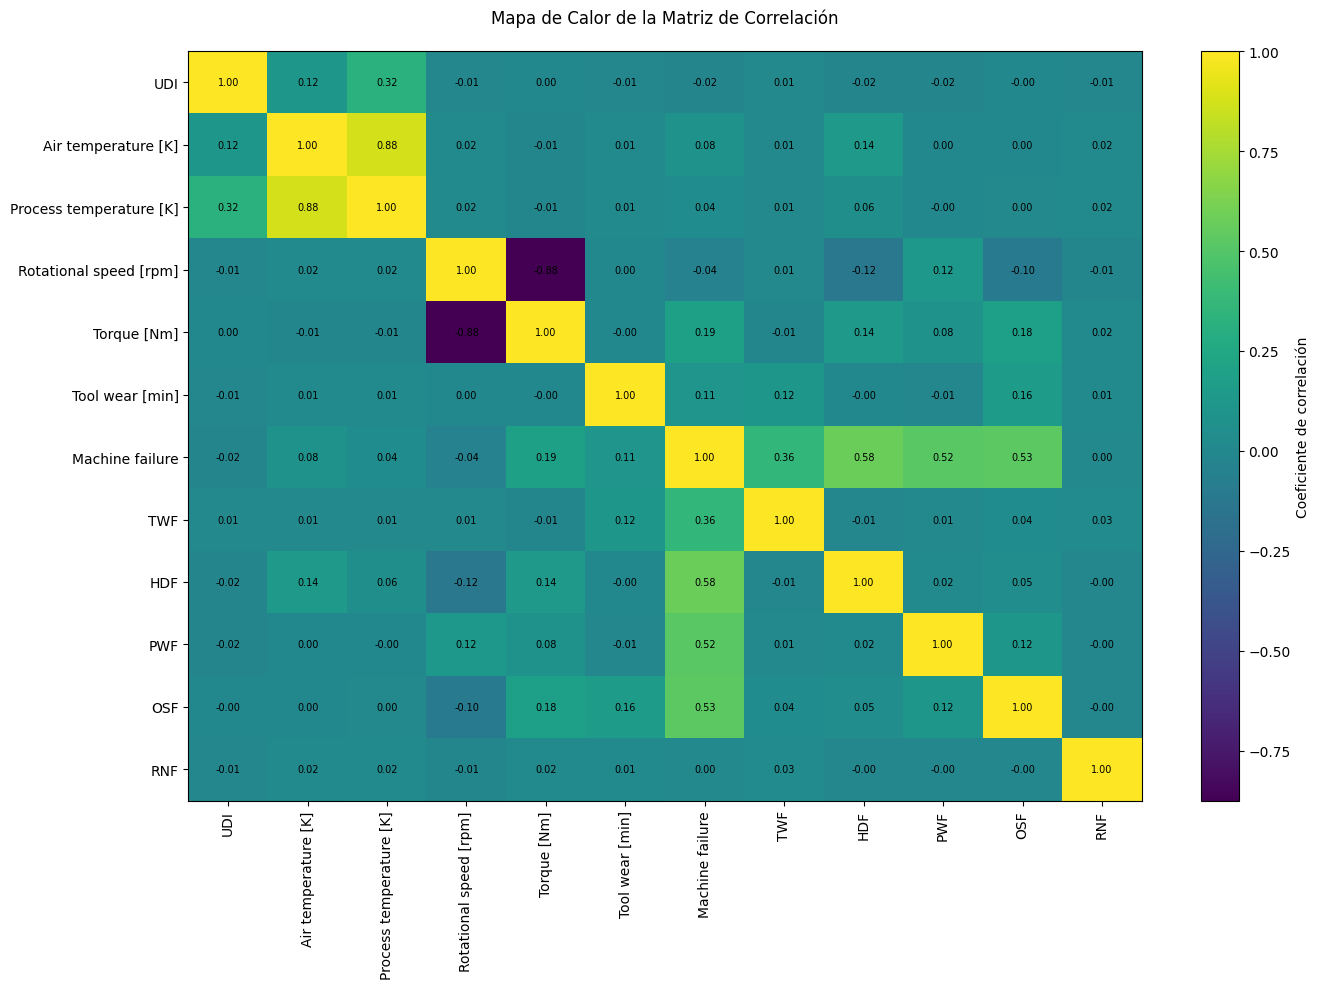

In [58]:
# ============================================================
# BLOQUE 3.8.3
# REPRESENTACIÓN GRÁFICA DE LA CORRELACIÓN
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("MAPA DE CALOR DE LA MATRIZ DE CORRELACIÓN")
print("=" * 70)

# Obtener los nombres de las variables numéricas
nombres_variables = correlacion.columns

# Crear la figura
plt.figure(figsize=(14, 10))

# Representar la matriz de correlación
imagen = plt.imshow(
    correlacion,
    aspect="auto",
    interpolation="nearest"
)

# Agregar barra lateral con la escala de correlación
plt.colorbar(
    imagen,
    label="Coeficiente de correlación"
)

# Configurar los nombres de las variables
plt.xticks(
    ticks=range(len(nombres_variables)),
    labels=nombres_variables,
    rotation=90
)

plt.yticks(
    ticks=range(len(nombres_variables)),
    labels=nombres_variables
)

# Agregar los valores numéricos dentro de cada celda
for fila in range(len(nombres_variables)):
    for columna in range(len(nombres_variables)):

        valor = correlacion.iloc[fila, columna]

        plt.text(
            columna,
            fila,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

# Configurar el título
plt.title(
    "Mapa de Calor de la Matriz de Correlación",
    pad=20
)

plt.tight_layout()

plt.show()

### Interpretación

El mapa de calor representa gráficamente los coeficientes de correlación existentes entre las variables numéricas del conjunto de datos.

Cada celda muestra el valor de correlación correspondiente a una pareja de variables. Los valores próximos a **1** indican una relación positiva fuerte, mientras que los valores cercanos a **-1** representan una relación negativa fuerte. Los valores próximos a **0** reflejan una baja asociación lineal.

La diagonal principal presenta valores iguales a **1**, debido a que cada variable mantiene una correlación perfecta consigo misma.

La representación permite observar que algunas variables operativas presentan asociaciones bajas o moderadas entre sí. También facilita la identificación de las variables específicas de falla que tienen una relación directa con **Machine failure**.

Sin embargo, estas variables de falla específica no se utilizarán automáticamente como características predictoras, ya que podrían revelar información posterior a la ocurrencia de la falla y generar fuga de información durante el entrenamiento.

### Conclusión

El análisis de correlación permitió estudiar las relaciones existentes entre las variables numéricas del dataset y su asociación con la variable objetivo **Machine failure**.

La matriz numérica, la tabla de correlación con la variable objetivo y el mapa de calor proporcionan evidencia útil para la selección de características.

No obstante, la correlación no será el único criterio utilizado para conservar o eliminar variables. También se considerará su significado dentro del proceso industrial y el riesgo de fuga de información.

Los resultados obtenidos servirán como fundamento técnico para el siguiente bloque, en el cual se realizará la depuración y preparación definitiva del dataset antes del entrenamiento del Árbol de Decisión.

# 4. Depuración y Preparación del Dataset

### Objetivo

En este bloque se realiza el proceso de preparación del conjunto de datos que será utilizado para entrenar el modelo de Árbol de Decisión.

Durante esta etapa se analizará la utilidad de cada variable, identificando aquellas que aportan información relevante para la predicción de fallas y aquellas que deben excluirse por no contribuir al proceso de aprendizaje o por generar fuga de información (Data Leakage).

Una adecuada selección de variables mejora la calidad del modelo, reduce la complejidad del entrenamiento y facilita la interpretación de los resultados obtenidos.


In [59]:
# ============================================================
# BLOQUE 4
# DEPURACIÓN Y PREPARACIÓN DEL DATASET
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("DEPURACIÓN Y PREPARACIÓN DEL DATASET")
print("=" * 70)

print("\nSe iniciará el proceso de selección de variables.")
print("Cada decisión será justificada antes de modificar")
print("el conjunto de datos.\n")

DEPURACIÓN Y PREPARACIÓN DEL DATASET

Se iniciará el proceso de selección de variables.
Cada decisión será justificada antes de modificar
el conjunto de datos.



### Interpretación

La preparación del dataset constituye una de las etapas más importantes del proceso de aprendizaje automático.

En este bloque se analizará cada variable desde el punto de vista estadístico y funcional, permitiendo determinar cuáles aportan información útil para la predicción de fallas y cuáles podrían afectar negativamente el entrenamiento del modelo.

Todas las decisiones de depuración estarán respaldadas por el análisis exploratorio realizado en los bloques anteriores.

## 4.1 Clasificación de las Variables del Dataset

Antes de iniciar la depuración, es conveniente clasificar las variables según la función que desempeñan dentro del conjunto de datos.

Esta clasificación facilita la comprensión del dataset y sirve como base para justificar las decisiones de selección de características que se realizarán posteriormente.

In [60]:
# ============================================================
# BLOQUE 4.1
# CLASIFICACIÓN DE LAS VARIABLES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

clasificacion = pd.DataFrame({

    "Variable": [

        "UDI",
        "Product ID",
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"

    ],

    "Clasificación": [

        "Identificador",
        "Identificador",
        "Variable categórica",
        "Variable operativa",
        "Variable operativa",
        "Variable operativa",
        "Variable operativa",
        "Variable operativa",
        "Variable objetivo",
        "Tipo de falla",
        "Tipo de falla",
        "Tipo de falla",
        "Tipo de falla",
        "Tipo de falla"

    ]

})

display(clasificacion)

,Variable,Clasificación
0,UDI,Identificador
1,Product ID,Identificador
2,Type,Variable categórica
3,Air temperature [K],Variable operativa
4,Process temperature [K],Variable operativa
5,Rotational speed [rpm],Variable operativa
6,Torque [Nm],Variable operativa
7,Tool wear [min],Variable operativa
8,Machine failure,Variable objetivo
9,TWF,Tipo de falla


### Interpretación

La clasificación evidencia que el conjunto de datos está conformado por diferentes tipos de variables.

Las variables de identificación permiten diferenciar cada registro, las variables operativas describen el comportamiento de la maquinaria, la variable objetivo representa el estado final de la máquina y las variables de tipo de falla indican la causa específica de una falla cuando esta ocurre.

Esta organización facilitará la selección de características durante las siguientes etapas de depuración.

## 4.2 Evaluación de las Variables de Identificación

En este apartado se analizan las variables **UDI** y **Product ID**, las cuales cumplen la función de identificar de manera única cada registro y cada producto dentro del conjunto de datos.

Aunque estas variables son útiles para la organización del dataset, no describen el estado operativo de la maquinaria ni contienen información relacionada con la ocurrencia de fallas.

Por esta razón, es necesario evaluar si su inclusión aporta valor al entrenamiento del modelo de Árbol de Decisión.

In [61]:
# ============================================================
# BLOQUE 4.2
# EVALUACIÓN DE LAS VARIABLES DE IDENTIFICACIÓN
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("EVALUACIÓN DE LAS VARIABLES DE IDENTIFICACIÓN")
print("=" * 70)

variables_identificacion = [
    "UDI",
    "Product ID"
]

for variable in variables_identificacion:
    print(f"• {variable}")

EVALUACIÓN DE LAS VARIABLES DE IDENTIFICACIÓN
• UDI
• Product ID


In [62]:
# ============================================================
# TABLA DE DECISIÓN
# VARIABLES DE IDENTIFICACIÓN
# ============================================================

decision_identificacion = pd.DataFrame({

    "Variable": [
        "UDI",
        "Product ID"
    ],

    "Clasificación": [
        "Identificador",
        "Identificador"
    ],

    "¿Se conserva?": [
        "No",
        "No"
    ],

    "Justificación": [

        "Identifica cada registro pero no aporta información predictiva.",

        "Identifica el producto pero no describe el comportamiento de la máquina."

    ]

})

display(decision_identificacion)

,Variable,Clasificación,¿Se conserva?,Justificación
0,UDI,Identificador,No,Identifica cada registro pero no aporta inform...
1,Product ID,Identificador,No,Identifica el producto pero no describe el com...


### Interpretación

El análisis confirma que las variables **UDI** y **Product ID** cumplen únicamente una función de identificación dentro del conjunto de datos.

Estas variables no representan condiciones de operación de la maquinaria ni mantienen una relación directa con la ocurrencia de fallas.

Su inclusión durante el entrenamiento podría incrementar la complejidad del modelo sin aportar capacidad predictiva, por lo que se recomienda excluirlas del conjunto de características utilizadas para el aprendizaje.

## 4.3 Evaluación de las Variables de Tipo de Falla

El conjunto de datos incluye cinco variables que indican el tipo específico de falla ocurrido durante la operación de la máquina:

- Tool Wear Failure (TWF)
- Heat Dissipation Failure (HDF)
- Power Failure (PWF)
- Overstrain Failure (OSF)
- Random Failure (RNF)

Aunque estas variables presentan una relación directa con la variable objetivo **Machine failure**, es necesario analizar cuidadosamente su utilización durante el entrenamiento del modelo.

En problemas de mantenimiento predictivo, utilizar estas variables como características de entrada puede generar un fenómeno conocido como **Data Leakage (fuga de información)**.

In [63]:
# ============================================================
# BLOQUE 4.3
# VARIABLES DE TIPO DE FALLA
# ============================================================

variables_falla = [

    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"

]

print("=" * 70)
print("VARIABLES DE TIPO DE FALLA")
print("=" * 70)

for variable in variables_falla:
    print(f"• {variable}")

VARIABLES DE TIPO DE FALLA
• TWF
• HDF
• PWF
• OSF
• RNF


## 4.3.1 Explicación del Data Leakage (Fuga de Información)

### Objetivo

En este apartado se analiza el fenómeno conocido como **Data Leakage** o **fuga de información**, el cual ocurre cuando el modelo utiliza durante el entrenamiento información que, en un escenario real, no estaría disponible en el momento de realizar una predicción.

En el dataset AI4I 2020, las variables **TWF**, **HDF**, **PWF**, **OSF** y **RNF** indican el tipo específico de falla que presentó la máquina.

Aunque estas variables presentan una alta relación con la variable objetivo **Machine failure**, utilizarlas como variables predictoras produciría un entrenamiento poco realista, ya que estarían revelando información posterior a la ocurrencia de la falla.

In [64]:
# ============================================================
# BLOQUE 4.3.1
# DATA LEAKAGE (FUGA DE INFORMACIÓN)
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("ANÁLISIS DE DATA LEAKAGE")
print("=" * 70)

descripcion_fallas = pd.DataFrame({

    "Variable": [
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ],

    "Significado": [
        "Tool Wear Failure",
        "Heat Dissipation Failure",
        "Power Failure",
        "Overstrain Failure",
        "Random Failure"
    ],

    "¿Genera Data Leakage?": [
        "Sí",
        "Sí",
        "Sí",
        "Sí",
        "Sí"
    ]

})

display(descripcion_fallas)

ANÁLISIS DE DATA LEAKAGE


,Variable,Significado,¿Genera Data Leakage?
0,TWF,Tool Wear Failure,Sí
1,HDF,Heat Dissipation Failure,Sí
2,PWF,Power Failure,Sí
3,OSF,Overstrain Failure,Sí
4,RNF,Random Failure,Sí


### Interpretación

Las variables **TWF**, **HDF**, **PWF**, **OSF** y **RNF** describen el tipo específico de falla que experimentó la máquina.

En un sistema de mantenimiento predictivo, el objetivo del modelo consiste en anticipar si una máquina presentará una falla antes de que esta ocurra.

Si estas variables se utilizaran durante el entrenamiento, el modelo tendría acceso a información que únicamente se conoce después de producirse la falla, generando un problema de **Data Leakage**.

Como consecuencia, el modelo podría obtener métricas artificialmente elevadas durante la evaluación, pero presentaría un desempeño inferior al ser utilizado en un entorno real.

## 4.3.2 Decisión sobre las Variables de Tipo de Falla

Con base en el análisis realizado, se presenta la decisión adoptada para cada una de las variables relacionadas con tipos específicos de falla.

Esta decisión tiene como objetivo garantizar que el modelo sea entrenado únicamente con información disponible antes de la ocurrencia de una falla.

In [65]:
# ============================================================
# BLOQUE 4.3.2
# DECISIÓN SOBRE LAS VARIABLES DE TIPO DE FALLA
# ============================================================

decision_fallas = pd.DataFrame({

    "Variable": [
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ],

    "¿Se conserva?": [
        "No",
        "No",
        "No",
        "No",
        "No"
    ],

    "Justificación": [

        "Provoca fuga de información.",

        "Provoca fuga de información.",

        "Provoca fuga de información.",

        "Provoca fuga de información.",

        "Provoca fuga de información."

    ]

})

display(decision_fallas)

,Variable,¿Se conserva?,Justificación
0,TWF,No,Provoca fuga de información.
1,HDF,No,Provoca fuga de información.
2,PWF,No,Provoca fuga de información.
3,OSF,No,Provoca fuga de información.
4,RNF,No,Provoca fuga de información.


### Interpretación

El análisis confirma que las cinco variables de tipo de falla deben excluirse del conjunto de características utilizadas para entrenar el modelo.

Aunque presentan una fuerte relación con la variable objetivo, esta asociación se debe a que describen el tipo de falla una vez que el evento ya ocurrió.

Eliminar estas variables garantiza que el Árbol de Decisión aprenda únicamente a partir de las condiciones operativas de la máquina, permitiendo desarrollar un modelo más realista y con mayor capacidad de generalización.

### Conclusión

La identificación y eliminación de variables que generan **Data Leakage** constituye una buena práctica en proyectos de aprendizaje automático.

En este proyecto se decidió excluir las variables **TWF**, **HDF**, **PWF**, **OSF** y **RNF**, ya que contienen información posterior al evento que se pretende predecir.

Esta decisión permitirá entrenar un modelo de Árbol de Decisión basado únicamente en variables que estarían disponibles en un escenario real de mantenimiento predictivo, obteniendo resultados más confiables y representativos.

## 4.4 Selección Final de Variables

Después del análisis exploratorio, la evaluación de las variables y la identificación de posibles casos de fuga de información (Data Leakage), se procede a establecer la selección definitiva de las variables que serán utilizadas durante el entrenamiento del modelo de Árbol de Decisión.

La siguiente tabla resume la decisión adoptada para cada variable del conjunto de datos, indicando si será conservada o eliminada junto con su respectiva justificación técnica.


In [66]:
# ============================================================
# BLOQUE 4.4
# SELECCIÓN FINAL DE VARIABLES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

seleccion_variables = pd.DataFrame({

    "Variable": [

        "UDI",
        "Product ID",
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"

    ],

    "Clasificación": [

        "Identificador",
        "Identificador",
        "Variable categórica",
        "Variable operativa",
        "Variable operativa",
        "Variable operativa",
        "Variable operativa",
        "Variable operativa",
        "Variable objetivo",
        "Tipo de falla",
        "Tipo de falla",
        "Tipo de falla",
        "Tipo de falla",
        "Tipo de falla"

    ],

    "¿Se conserva?": [

        "No",
        "No",
        "Sí",
        "Sí",
        "Sí",
        "Sí",
        "Sí",
        "Sí",
        "Sí",
        "No",
        "No",
        "No",
        "No",
        "No"

    ],

    "Justificación": [

        "Identificador único del registro.",

        "Identificador del producto.",

        "Característica del tipo de producto.",

        "Variable operativa relevante.",

        "Variable operativa relevante.",

        "Variable operativa relevante.",

        "Variable operativa relevante.",

        "Variable operativa relevante.",

        "Variable objetivo del modelo.",

        "Genera Data Leakage.",

        "Genera Data Leakage.",

        "Genera Data Leakage.",

        "Genera Data Leakage.",

        "Genera Data Leakage."

    ]

})

display(seleccion_variables)

,Variable,Clasificación,¿Se conserva?,Justificación
0,UDI,Identificador,No,Identificador único del registro.
1,Product ID,Identificador,No,Identificador del producto.
2,Type,Variable categórica,Sí,Característica del tipo de producto.
3,Air temperature [K],Variable operativa,Sí,Variable operativa relevante.
4,Process temperature [K],Variable operativa,Sí,Variable operativa relevante.
5,Rotational speed [rpm],Variable operativa,Sí,Variable operativa relevante.
6,Torque [Nm],Variable operativa,Sí,Variable operativa relevante.
7,Tool wear [min],Variable operativa,Sí,Variable operativa relevante.
8,Machine failure,Variable objetivo,Sí,Variable objetivo del modelo.
9,TWF,Tipo de falla,No,Genera Data Leakage.


### Interpretación

La tabla resume las decisiones adoptadas durante el proceso de selección de variables.

Se conservarán únicamente aquellas características que describen las condiciones de operación de la maquinaria y que estarán disponibles antes de que ocurra una falla.

Por el contrario, las variables de identificación y las relacionadas con tipos específicos de falla serán excluidas, ya que no aportan capacidad predictiva o introducen información que no estaría disponible durante una predicción real.

Esta selección permitirá entrenar un modelo más robusto, interpretable y con mayor capacidad de generalización.

## 4.5 Depuración del Dataset

Una vez definidas las variables que se conservarán y aquellas que serán eliminadas, se procede a realizar la depuración del conjunto de datos.

Durante este proceso se eliminarán las variables de identificación y las variables asociadas a tipos específicos de falla, conservando únicamente las características necesarias para entrenar el modelo de Árbol de Decisión.

In [67]:
# ============================================================
# BLOQUE 4.5
# DEPURACIÓN DEL DATASET
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 65)
print("DEPURACIÓN DEL DATASET")
print("=" * 65)

columnas_eliminar = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

# Identificar cuáles columnas todavía están disponibles
columnas_disponibles = [
    columna
    for columna in columnas_eliminar
    if columna in dataset.columns
]

# Eliminar únicamente las columnas que todavía existen
dataset = dataset.drop(
    columns=columnas_disponibles,
    errors="ignore"
)

if columnas_disponibles:

    print("\nVariables eliminadas correctamente:\n")

    for columna in columnas_disponibles:
        print(f"• {columna}")

else:

    print("\nLas variables ya habían sido eliminadas anteriormente.")

print(f"\nNúmero de registros: {dataset.shape[0]}")
print(f"Número de columnas: {dataset.shape[1]}")

print("\nBloque 4.5 ejecutado correctamente.")

DEPURACIÓN DEL DATASET

Variables eliminadas correctamente:

• UDI
• Product ID
• TWF
• HDF
• PWF
• OSF
• RNF

Número de registros: 10000
Número de columnas: 7

Bloque 4.5 ejecutado correctamente.


In [68]:
# ============================================================
# VERIFICACIÓN DEL DATASET DEPURADO
# ============================================================

display(dataset.head())

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


### Interpretación

Después de la depuración, el conjunto de datos conserva únicamente las variables necesarias para el entrenamiento del modelo.

Las variables eliminadas correspondían a identificadores o a información que podía generar fuga de información durante el aprendizaje.

El nuevo dataset mantiene la variable objetivo **Machine failure** y las variables operativas que describen el comportamiento de la maquinaria, garantizando una base adecuada para el entrenamiento del Árbol de Decisión.

## 4.5.1 Verificación de la Eliminación de Variables

Después de eliminar las variables no seleccionadas, es necesario verificar que el conjunto de datos conserve únicamente las características que serán utilizadas durante el entrenamiento del modelo.

Esta validación permite confirmar que el proceso de depuración se realizó correctamente y que el dataset se encuentra listo para la siguiente etapa de preparación de los datos.

In [69]:
# ============================================================
# BLOQUE 4.5.1
# VERIFICACIÓN DE LA ELIMINACIÓN DE VARIABLES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("VERIFICACIÓN DE LA ELIMINACIÓN DE VARIABLES")
print("=" * 70)

print("\nNúmero de variables después de la depuración:")

print(dataset.shape[1])

print("\nVariables disponibles:\n")

for numero, columna in enumerate(dataset.columns, start=1):

    print(f"{numero}. {columna}")

VERIFICACIÓN DE LA ELIMINACIÓN DE VARIABLES

Número de variables después de la depuración:
7

Variables disponibles:

1. Type
2. Air temperature [K]
3. Process temperature [K]
4. Rotational speed [rpm]
5. Torque [Nm]
6. Tool wear [min]
7. Machine failure


### Interpretación

La verificación confirma que las variables de identificación y las variables asociadas a tipos específicos de falla fueron eliminadas correctamente.

El conjunto de datos conserva únicamente las variables que describen las condiciones de operación de la maquinaria, además de la variable objetivo **Machine failure**, la cual será utilizada durante el entrenamiento del modelo de Árbol de Decisión.

Esta estructura garantiza que el modelo aprenda exclusivamente a partir de información disponible antes de la ocurrencia de una falla.

## 4.5.2 Vista Preliminar del Dataset Depurado

Una vez realizada la depuración, se presenta una vista preliminar del conjunto de datos resultante.

Esta inspección permite comprobar visualmente la estructura final del dataset y verificar que únicamente permanecen las variables seleccionadas para el entrenamiento del modelo.

In [70]:
# ============================================================
# BLOQUE 4.5.2
# VISTA PRELIMINAR DEL DATASET DEPURADO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("VISTA PRELIMINAR DEL DATASET DEPURADO")
print("=" * 70)

display(dataset.head())

VISTA PRELIMINAR DEL DATASET DEPURADO


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


### Interpretación

La vista preliminar confirma que el conjunto de datos fue depurado correctamente y conserva únicamente las variables necesarias para el proceso de aprendizaje automático.

Las variables operativas continúan describiendo las condiciones de funcionamiento de la maquinaria, mientras que la variable **Machine failure** permanece como la variable objetivo que será utilizada para entrenar el modelo de clasificación.

El dataset obtenido constituye la base sobre la cual se desarrollarán las siguientes etapas del proyecto.


## 4.5.3 Resumen de la Depuración

Como cierre del proceso de depuración, se presenta un resumen cuantitativo de las variables originales, las variables eliminadas y las variables que conforman el conjunto de datos final.

Este resumen facilita la comprensión de las modificaciones realizadas antes de iniciar la preparación del dataset para el entrenamiento del modelo.

In [71]:
# ============================================================
# BLOQUE 4.5.3
# RESUMEN DE LA DEPURACIÓN
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

resumen_depuracion = pd.DataFrame({

    "Concepto": [

        "Variables originales",
        "Variables eliminadas",
        "Variables finales"

    ],

    "Cantidad": [

        14,
        len(columnas_eliminar),
        dataset.shape[1]

    ]

})

display(resumen_depuracion)

,Concepto,Cantidad
0,Variables originales,14
1,Variables eliminadas,7
2,Variables finales,7


### Interpretación

El proceso de depuración permitió reducir el número de variables del conjunto de datos, eliminando aquellas que no aportaban capacidad predictiva o que podían introducir fuga de información durante el entrenamiento del modelo.

Como resultado, el dataset final conserva únicamente las variables relevantes para el desarrollo del sistema de mantenimiento predictivo basado en Árbol de Decisión.

# 5. Preparación de los Datos para el Entrenamiento

### Objetivo

En este bloque se prepara el conjunto de datos que será utilizado para entrenar el modelo de Árbol de Decisión.

Durante esta etapa se realizará la codificación de la variable categórica **Type**, la separación de las variables predictoras y la variable objetivo, así como la división del conjunto de datos en entrenamiento y prueba.

Estas operaciones permiten transformar el dataset depurado en una estructura adecuada para el aprendizaje automático.

In [72]:
# ============================================================
# BLOQUE 5
# PREPARACIÓN DE LOS DATOS PARA EL ENTRENAMIENTO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("PREPARACIÓN DE LOS DATOS PARA EL ENTRENAMIENTO")
print("=" * 70)

print("\nSe realizará la codificación de la variable categórica,")
print("la separación de las variables predictoras y la variable")
print("objetivo, y la división en entrenamiento y prueba.\n")

PREPARACIÓN DE LOS DATOS PARA EL ENTRENAMIENTO

Se realizará la codificación de la variable categórica,
la separación de las variables predictoras y la variable
objetivo, y la división en entrenamiento y prueba.



### Interpretación

En este bloque se transformará el dataset depurado en una estructura compatible con el modelo de Árbol de Decisión.

El proceso incluye la conversión de la variable categórica **Type** a valores numéricos, la definición de las variables predictoras y la división de los datos para entrenar y evaluar el modelo de manera independiente.

## 5.1 Codificación de la Variable Categórica Type

La variable **Type** representa el tipo de producto y contiene tres categorías:

- **L:** producto de calidad baja.
- **M:** producto de calidad media.
- **H:** producto de calidad alta.

Los algoritmos de aprendizaje automático requieren que las variables de entrada se encuentren representadas numéricamente.

Por esta razón, la variable **Type** será transformada mediante la técnica **One-Hot Encoding**, la cual crea una columna binaria para cada categoría sin establecer un orden artificial entre ellas.

In [73]:
# ============================================================
# BLOQUE 5.1
# CODIFICACIÓN DE LA VARIABLE CATEGÓRICA TYPE
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("CODIFICACIÓN DE LA VARIABLE TYPE")
print("=" * 70)

# Mostrar las categorías originales
print("\nCategorías originales de Type:")

print(dataset["Type"].value_counts().sort_index())

CODIFICACIÓN DE LA VARIABLE TYPE

Categorías originales de Type:
Type
H    1003
L    6000
M    2997
Name: count, dtype: int64


### Interpretación

La variable **Type** contiene tres categorías distintas: **L**, **M** y **H**.

Estas categorías representan tipos de producto, pero no poseen un orden numérico natural. Por este motivo, no se recomienda asignar valores como 1, 2 y 3, ya que el modelo podría interpretar erróneamente que una categoría es mayor que otra.

La técnica One-Hot Encoding evita este problema al crear variables binarias independientes para cada categoría.

## 5.1.1 Aplicación de One-Hot Encoding

En este apartado se transforma la variable categórica **Type** en columnas numéricas binarias.

Se utiliza la función **get_dummies()** de Pandas, la cual genera una columna independiente para cada categoría.

Se eliminará una de las columnas resultantes mediante el parámetro `drop_first=True`, evitando redundancia entre las variables creadas.

In [74]:
# ============================================================
# BLOQUE 5.1.1
# APLICACIÓN DE ONE-HOT ENCODING
# ============================================================

dataset_codificado = pd.get_dummies(
    dataset,
    columns=["Type"],
    drop_first=True,
    dtype=int
)

print("=" * 70)
print("VARIABLE TYPE CODIFICADA CORRECTAMENTE")
print("=" * 70)

print("\nVariables disponibles después de la codificación:\n")

for numero, columna in enumerate(dataset_codificado.columns, start=1):
    print(f"{numero}. {columna}")

VARIABLE TYPE CODIFICADA CORRECTAMENTE

Variables disponibles después de la codificación:

1. Air temperature [K]
2. Process temperature [K]
3. Rotational speed [rpm]
4. Torque [Nm]
5. Tool wear [min]
6. Machine failure
7. Type_L
8. Type_M


### Interpretación

La técnica One-Hot Encoding transformó la variable categórica **Type** en variables binarias.

Cada nueva columna indica si un registro pertenece o no a una categoría determinada:

- Un valor de **1** indica que el registro pertenece a esa categoría.
- Un valor de **0** indica que no pertenece a ella.

La opción `drop_first=True` elimina una categoría de referencia para evitar información redundante. La categoría eliminada puede identificarse cuando todas las columnas creadas presentan el valor cero.

## 5.1.2 Verificación del Dataset Codificado

Después de aplicar la codificación, se realiza una inspección del conjunto de datos para verificar que la variable **Type** fue transformada correctamente y que las demás variables permanecen sin modificaciones.

In [75]:
# ============================================================
# BLOQUE 5.1.2
# VERIFICACIÓN DEL DATASET CODIFICADO
# ============================================================

print("=" * 70)
print("VISTA PRELIMINAR DEL DATASET CODIFICADO")
print("=" * 70)

display(dataset_codificado.head())

VISTA PRELIMINAR DEL DATASET CODIFICADO


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


### Interpretación

La vista preliminar permite comprobar que la columna original **Type** fue reemplazada por variables numéricas binarias.

El dataset se encuentra ahora compuesto únicamente por variables numéricas, condición necesaria para continuar con la separación de las variables predictoras y la variable objetivo.

## 5.2 Separación de Variables Predictoras y Variable Objetivo

Una vez finalizada la codificación de las variables categóricas, el siguiente paso consiste en separar el conjunto de datos en variables predictoras (**X**) y variable objetivo (**y**).

Las variables predictoras corresponden a las características utilizadas por el modelo para aprender los patrones presentes en los datos, mientras que la variable objetivo representa la clase que el algoritmo deberá predecir.

Esta separación constituye una etapa fundamental dentro del proceso de entrenamiento de cualquier modelo de aprendizaje supervisado.

In [76]:
# ============================================================
# BLOQUE 5.2
# SEPARACIÓN DE VARIABLES PREDICTORAS Y VARIABLE OBJETIVO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("SEPARACIÓN DE VARIABLES PREDICTORAS Y VARIABLE OBJETIVO")
print("=" * 70)

# Variables predictoras
X = dataset_codificado.drop(columns=["Machine failure"])

# Variable objetivo
y = dataset_codificado["Machine failure"]

print("\nVariables predictoras (X):")

display(X.head())

print("\nVariable objetivo (y):")

display(y.head())

SEPARACIÓN DE VARIABLES PREDICTORAS Y VARIABLE OBJETIVO

Variables predictoras (X):


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,1
1,298.2,308.7,1408,46.3,3,1,0
2,298.1,308.5,1498,49.4,5,1,0
3,298.2,308.6,1433,39.5,7,1,0
4,298.2,308.7,1408,40.0,9,1,0



Variable objetivo (y):


,Machine failure
0,0
1,0
2,0
3,0
4,0


### Interpretación

La separación realizada permite distinguir claramente las variables utilizadas como entrada del modelo y la variable que representa el resultado esperado.

Las variables predictoras (**X**) contienen la información relacionada con las condiciones de operación de la maquinaria, mientras que la variable objetivo (**y**) indica si la máquina presentó o no una falla.

Esta organización será utilizada durante el entrenamiento del modelo de Árbol de Decisión.

## 5.2.1 Verificación de las Dimensiones

Después de separar las variables predictoras y la variable objetivo, es conveniente verificar sus dimensiones para confirmar que el proceso se realizó correctamente.

Esta validación permite asegurar que ambas estructuras contienen el mismo número de registros y que el número de variables predictoras coincide con las características seleccionadas durante la etapa de depuración.

In [77]:
# ============================================================
# BLOQUE 5.2.1
# VERIFICACIÓN DE DIMENSIONES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("DIMENSIONES DE X Y y")
print("=" * 70)

print(f"\nDimensiones de X: {X.shape}")

print(f"Dimensiones de y: {y.shape}")

DIMENSIONES DE X Y y

Dimensiones de X: (10000, 7)
Dimensiones de y: (10000,)


### Interpretación

Las dimensiones obtenidas confirman que la separación se realizó correctamente.

La matriz **X** contiene todas las variables predictoras seleccionadas durante el proceso de depuración, mientras que el vector **y** almacena la variable objetivo correspondiente a cada registro.

La igualdad en el número de observaciones garantiza que cada conjunto de características posee su respectiva etiqueta de clasificación.

## 5.2.2 Identificación de las Variables Predictoras

Como parte de la preparación del conjunto de datos, se presenta el listado definitivo de las variables que serán utilizadas por el modelo de Árbol de Decisión durante el entrenamiento.

Esta verificación permite confirmar que únicamente permanecen las características seleccionadas durante el proceso de depuración.

In [78]:
# ============================================================
# BLOQUE 5.2.2
# VARIABLES PREDICTORAS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("VARIABLES PREDICTORAS")
print("=" * 70)

for numero, variable in enumerate(X.columns, start=1):

    print(f"{numero}. {variable}")

VARIABLES PREDICTORAS
1. Air temperature [K]
2. Process temperature [K]
3. Rotational speed [rpm]
4. Torque [Nm]
5. Tool wear [min]
6. Type_L
7. Type_M


### Interpretación

El listado confirma las variables que serán utilizadas por el modelo durante el proceso de entrenamiento.

Estas características representan las condiciones de operación de la maquinaria y constituyen la información disponible antes de que ocurra una posible falla.

La selección realizada garantiza que el modelo aprenda únicamente a partir de variables con capacidad predictiva y evita la incorporación de información que pueda generar fuga de información (Data Leakage).

## 5.3 División del Dataset en Entrenamiento y Prueba

Una vez definidas las variables predictoras y la variable objetivo, el siguiente paso consiste en dividir el conjunto de datos en dos subconjuntos:

- **Conjunto de entrenamiento (Training Set):** utilizado para que el modelo aprenda los patrones presentes en los datos.
- **Conjunto de prueba (Test Set):** utilizado para evaluar el desempeño del modelo sobre información que no fue utilizada durante el entrenamiento.

En este proyecto se utilizará una división del **80 % para entrenamiento** y **20 % para prueba**, proporción ampliamente utilizada en proyectos de aprendizaje automático por ofrecer un adecuado equilibrio entre aprendizaje y evaluación.

In [79]:
# ============================================================
# BLOQUE 5.3
# DIVISIÓN DEL DATASET EN ENTRENAMIENTO Y PRUEBA
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 70)
print("DIVISIÓN DEL DATASET")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,
    random_state=42,
    stratify=y

)

print("\nDivisión realizada correctamente.")

DIVISIÓN DEL DATASET

División realizada correctamente.


### Interpretación

El conjunto de datos fue dividido en dos subconjuntos independientes.

El **80 %** de los registros será utilizado para entrenar el modelo, mientras que el **20 %** restante servirá para evaluar su capacidad de predicción sobre datos no vistos previamente.

Además, se empleó el parámetro **stratify=y**, garantizando que la proporción de registros con y sin falla permanezca similar tanto en el conjunto de entrenamiento como en el de prueba.

## 5.3.1 Verificación de las Dimensiones

Después de realizar la división del conjunto de datos, es importante verificar las dimensiones de cada subconjunto obtenido.

Esta validación permite confirmar que la separación se realizó correctamente y que cada conjunto contiene el número esperado de registros y variables.

In [80]:
# ============================================================
# BLOQUE 5.3.1
# DIMENSIONES DE LOS CONJUNTOS
# ============================================================

print("=" * 70)
print("DIMENSIONES DE LOS CONJUNTOS")
print("=" * 70)

print(f"\nX_train: {X_train.shape}")

print(f"X_test : {X_test.shape}")

print(f"y_train: {y_train.shape}")

print(f"y_test : {y_test.shape}")

DIMENSIONES DE LOS CONJUNTOS

X_train: (8000, 7)
X_test : (2000, 7)
y_train: (8000,)
y_test : (2000,)


### Interpretación

Las dimensiones obtenidas confirman que la división del conjunto de datos fue realizada correctamente.

Los datos de entrenamiento contienen la mayor parte de las observaciones y serán utilizados para construir el modelo de Árbol de Decisión.

Por su parte, los datos de prueba permanecerán completamente independientes hasta la etapa de evaluación, permitiendo medir objetivamente el desempeño del modelo.

## 5.3.2 Verificación de la Distribución de Clases

Debido a que la variable objetivo presenta una distribución desbalanceada, es importante comprobar que dicha proporción se mantiene después de dividir el conjunto de datos.

Esta verificación confirma el correcto funcionamiento del parámetro **stratify**, garantizando que tanto el conjunto de entrenamiento como el conjunto de prueba conserven una representación adecuada de ambas clases.

In [81]:
# ============================================================
# BLOQUE 5.3.2
# DISTRIBUCIÓN DE LAS CLASES
# ============================================================

print("=" * 70)
print("DISTRIBUCIÓN DE LAS CLASES")
print("=" * 70)

print("\nEntrenamiento:")

display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nPrueba:")

display(y_test.value_counts(normalize=True).mul(100).round(2))

DISTRIBUCIÓN DE LAS CLASES

Entrenamiento:


,proportion
Machine failure,
0,96.61
1,3.39



Prueba:


,proportion
Machine failure,
0,96.6
1,3.4


### Interpretación

La distribución porcentual de la variable objetivo en los conjuntos de entrenamiento y prueba es prácticamente la misma.

Este resultado confirma que la utilización del parámetro **stratify=y** permitió conservar el equilibrio relativo entre las clases, evitando que una de ellas quedara subrepresentada durante el entrenamiento o la evaluación del modelo.

Esta práctica mejora la confiabilidad de las métricas obtenidas y favorece una evaluación más representativa del desempeño del Árbol de Decisión.

### Conclusión

La preparación del conjunto de datos finalizó con la división en entrenamiento y prueba, obteniendo dos subconjuntos independientes y representativos de la distribución original del dataset.

La utilización de una división **80 % / 20 %**, junto con el parámetro **stratify**, garantiza que el modelo sea entrenado y evaluado bajo condiciones apropiadas, contribuyendo a obtener resultados confiables y reproducibles.

El conjunto de datos se encuentra ahora listo para iniciar el proceso de construcción y entrenamiento del modelo de Árbol de Decisión.

# 6. Construcción del Modelo de Árbol de Decisión

### Objetivo

En este bloque se construirá el modelo de Árbol de Decisión que será utilizado para predecir la ocurrencia de fallas en maquinaria industrial.

Durante esta etapa se configurarán los principales hiperparámetros del algoritmo, se entrenará el modelo utilizando el conjunto de entrenamiento y se realizará una primera inspección de la estructura generada.

La construcción adecuada del modelo constituye la base para las etapas posteriores de evaluación, interpretación y comparación con otros algoritmos de aprendizaje automático.

In [82]:
# ============================================================
# BLOQUE 6
# CONSTRUCCIÓN DEL MODELO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("CONSTRUCCIÓN DEL MODELO DE ÁRBOL DE DECISIÓN")
print("=" * 70)

print("\nSe construirá el modelo utilizando")
print("el conjunto de entrenamiento preparado")
print("en el bloque anterior.\n")

CONSTRUCCIÓN DEL MODELO DE ÁRBOL DE DECISIÓN

Se construirá el modelo utilizando
el conjunto de entrenamiento preparado
en el bloque anterior.



### Interpretación

En este bloque se desarrollará el modelo predictivo basado en Árbol de Decisión.

El algoritmo aprenderá automáticamente las reglas de clasificación a partir de las variables operativas de la maquinaria, generando una estructura jerárquica que permitirá clasificar nuevos registros según la probabilidad de presentar una falla.

## 6.1 Importación del Algoritmo

Antes de construir el modelo es necesario importar la implementación del algoritmo **DecisionTreeClassifier** disponible en la biblioteca Scikit-learn.

Esta clase proporciona las herramientas necesarias para entrenar modelos de clasificación basados en árboles de decisión.

In [83]:
# ============================================================
# BLOQUE 6.1
# IMPORTACIÓN DEL ALGORITMO
# ============================================================

from sklearn.tree import DecisionTreeClassifier

print("=" * 70)
print("ALGORITMO IMPORTADO CORRECTAMENTE")
print("=" * 70)

ALGORITMO IMPORTADO CORRECTAMENTE


### Interpretación

La clase **DecisionTreeClassifier** implementa el algoritmo de Árbol de Decisión para problemas de clasificación.

Esta herramienta permitirá construir un modelo capaz de aprender reglas de decisión a partir de las variables predictoras del conjunto de entrenamiento.

## 6.2 Configuración del Modelo

Antes del entrenamiento es necesario definir los principales hiperparámetros del algoritmo.

Los hiperparámetros controlan el comportamiento del Árbol de Decisión, determinando aspectos como la profundidad máxima, el criterio utilizado para seleccionar las divisiones y la reproducibilidad de los resultados.

Una adecuada configuración contribuye a reducir el riesgo de sobreajuste y mejora la capacidad de generalización del modelo.

In [84]:
# ============================================================
# BLOQUE 6.2
# CONFIGURACIÓN DEL MODELO
# ============================================================

modelo = DecisionTreeClassifier(

    criterion="gini",
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42

)

print("=" * 70)
print("MODELO CONFIGURADO")
print("=" * 70)

print(modelo)

MODELO CONFIGURADO
DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)


### Interpretación

El modelo fue configurado utilizando el criterio **Gini**, ampliamente empleado en problemas de clasificación por su eficiencia para medir la impureza de los nodos.

Además, se estableció una profundidad máxima de **6 niveles**, junto con restricciones sobre el número mínimo de muestras requeridas para dividir un nodo y para formar una hoja.

Estas configuraciones ayudan a controlar la complejidad del árbol, disminuyendo el riesgo de sobreajuste y favoreciendo una mejor capacidad de generalización sobre nuevos datos.

## 6.3 Justificación de los Hiperparámetros

Los hiperparámetros constituyen configuraciones establecidas por el desarrollador antes del entrenamiento del modelo.

A diferencia de los parámetros internos, los hiperparámetros no son aprendidos automáticamente durante el proceso de entrenamiento, sino que determinan el comportamiento del algoritmo y pueden influir significativamente en su desempeño.

En este proyecto se seleccionaron hiperparámetros orientados a construir un modelo con buena capacidad de generalización, evitando la generación de árboles excesivamente complejos que puedan presentar sobreajuste.

In [85]:
# ============================================================
# BLOQUE 6.3
# HIPERPARÁMETROS DEL MODELO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("HIPERPARÁMETROS CONFIGURADOS")
print("=" * 70)

hiperparametros = {

    "criterion": "gini",
    "max_depth": 6,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "random_state": 42

}

for parametro, valor in hiperparametros.items():

    print(f"{parametro}: {valor}")

HIPERPARÁMETROS CONFIGURADOS
criterion: gini
max_depth: 6
min_samples_split: 20
min_samples_leaf: 10
random_state: 42


### Interpretación

La configuración presentada corresponde a los hiperparámetros que serán utilizados durante el entrenamiento del modelo de Árbol de Decisión.

Estos parámetros determinan el comportamiento del algoritmo antes de iniciar el proceso de aprendizaje y permiten controlar aspectos importantes como la profundidad del árbol, el criterio de división de los nodos y las condiciones mínimas para generar nuevas ramas.

La adecuada selección de estos hiperparámetros contribuye a obtener un modelo más estable, interpretable y con mayor capacidad para generalizar sobre nuevos datos.

## 6.3.1 Explicación de los Hiperparámetros

Cada uno de los hiperparámetros seleccionados cumple una función específica dentro del proceso de construcción del Árbol de Decisión.

Su correcta configuración permite controlar la complejidad del modelo, reducir el riesgo de sobreajuste y mejorar la capacidad de predicción sobre nuevos datos.

In [86]:
# ============================================================
# BLOQUE 6.3.1
# DESCRIPCIÓN DE LOS HIPERPARÁMETROS
# ============================================================

descripcion = pd.DataFrame({

    "Hiperparámetro":[

        "criterion",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "random_state"

    ],

    "Valor":[

        "gini",
        6,
        20,
        10,
        42

    ],

    "Descripción":[

        "Criterio utilizado para dividir los nodos.",

        "Profundidad máxima permitida para el árbol.",

        "Número mínimo de muestras necesarias para dividir un nodo.",

        "Número mínimo de muestras permitido en cada hoja.",

        "Garantiza resultados reproducibles."

    ]

})

display(descripcion)

,Hiperparámetro,Valor,Descripción
0,criterion,gini,Criterio utilizado para dividir los nodos.
1,max_depth,6,Profundidad máxima permitida para el árbol.
2,min_samples_split,20,Número mínimo de muestras necesarias para divi...
3,min_samples_leaf,10,Número mínimo de muestras permitido en cada hoja.
4,random_state,42,Garantiza resultados reproducibles.


### Interpretación

Los hiperparámetros seleccionados buscan obtener un equilibrio entre precisión y capacidad de generalización.

El criterio **Gini** permite identificar las divisiones que producen nodos más homogéneos, mientras que la profundidad máxima limita el crecimiento del árbol para evitar modelos excesivamente complejos.

De igual forma, los parámetros **min_samples_split** y **min_samples_leaf** restringen la creación de divisiones poco representativas, contribuyendo a disminuir el riesgo de sobreajuste.

Finalmente, el parámetro **random_state** garantiza que el proceso pueda reproducirse exactamente en futuras ejecuciones.

## 6.3.2 Justificación Técnica de la Configuración

La configuración seleccionada fue definida considerando las características del conjunto de datos utilizado en este proyecto.

El dataset AI4I 2020 presenta una cantidad considerable de registros y una distribución desbalanceada entre las clases, por lo que resulta conveniente limitar el crecimiento del árbol para evitar que el modelo memorice los datos de entrenamiento.

La combinación de los hiperparámetros seleccionados permite construir un modelo interpretable, estable y con buena capacidad para generalizar sobre nuevos registros.

In [87]:
# ============================================================
# BLOQUE 6.3.2
# JUSTIFICACIÓN TÉCNICA DE LOS HIPERPARÁMETROS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

justificacion = pd.DataFrame({

    "Hiperparámetro":[

        "criterion",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "random_state"

    ],

    "Valor":[

        "gini",
        6,
        20,
        10,
        42

    ],

    "Beneficio esperado":[

        "Seleccionar divisiones más homogéneas.",

        "Evitar árboles demasiado profundos.",

        "Reducir divisiones poco representativas.",

        "Evitar hojas con muy pocos registros.",

        "Garantizar resultados reproducibles."

    ]

})

display(justificacion)

,Hiperparámetro,Valor,Beneficio esperado
0,criterion,gini,Seleccionar divisiones más homogéneas.
1,max_depth,6,Evitar árboles demasiado profundos.
2,min_samples_split,20,Reducir divisiones poco representativas.
3,min_samples_leaf,10,Evitar hojas con muy pocos registros.
4,random_state,42,Garantizar resultados reproducibles.


### Interpretación

La tabla presenta los hiperparámetros configurados para el modelo de Árbol de Decisión, junto con el valor asignado y el beneficio esperado de cada uno.

La selección de estos hiperparámetros busca controlar la complejidad del modelo, mejorar su capacidad para generalizar sobre nuevos datos y reducir el riesgo de sobreajuste.

Cada configuración fue definida considerando las características del conjunto de datos AI4I 2020 y el objetivo de construir un modelo robusto, interpretable y reproducible para la predicción de fallas en maquinaria industrial.

### Conclusión

La configuración establecida proporciona un punto de partida adecuado para el entrenamiento del modelo de Árbol de Decisión.

Los hiperparámetros fueron seleccionados con el propósito de controlar la complejidad del árbol y obtener un equilibrio entre capacidad predictiva, interpretabilidad y generalización.

En el siguiente apartado se utilizará esta configuración para entrenar el modelo utilizando el conjunto de datos preparado en los bloques anteriores.

## 6.4 Entrenamiento del Modelo

En este apartado se realiza el entrenamiento del modelo de Árbol de Decisión utilizando el conjunto de datos preparado en los bloques anteriores.

Durante el entrenamiento, el algoritmo analiza las variables predictoras y aprende automáticamente las reglas de decisión necesarias para clasificar si una máquina presentará o no una falla.

Como parte del proceso también se medirá el tiempo requerido para entrenar el modelo, información que posteriormente permitirá comparar el rendimiento del Árbol de Decisión con otros modelos de aprendizaje automático.

In [88]:
# ============================================================
# BLOQUE 6.4
# ENTRENAMIENTO DEL MODELO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

import time

print("=" * 70)
print("ENTRENAMIENTO DEL MODELO")
print("=" * 70)

inicio = time.time()

modelo.fit(X_train, y_train)

fin = time.time()

tiempo_entrenamiento = fin - inicio

print("\nEntrenamiento finalizado correctamente.")

ENTRENAMIENTO DEL MODELO

Entrenamiento finalizado correctamente.


### Interpretación

Durante esta etapa el algoritmo analizó el conjunto de entrenamiento para identificar patrones que permitan diferenciar máquinas con funcionamiento normal de aquellas que presentan una falla.

El modelo construyó automáticamente una estructura jerárquica de decisiones utilizando las variables operativas del dataset, generando las reglas que serán empleadas posteriormente para realizar predicciones sobre nuevos registros.

## 6.4.1 Tiempo de Entrenamiento

El tiempo de entrenamiento representa el intervalo requerido por el algoritmo para construir el modelo a partir del conjunto de entrenamiento.

Este indicador resulta útil para comparar posteriormente la eficiencia computacional del Árbol de Decisión con otros modelos de aprendizaje automático.

In [89]:
# ============================================================
# BLOQUE 6.4.1
# TIEMPO DE ENTRENAMIENTO
# ============================================================

print("=" * 70)
print("TIEMPO DE ENTRENAMIENTO")
print("=" * 70)

print(f"\nTiempo empleado: {tiempo_entrenamiento:.6f} segundos")

TIEMPO DE ENTRENAMIENTO

Tiempo empleado: 0.025221 segundos


### Interpretación

El tiempo obtenido corresponde al proceso completo de construcción del Árbol de Decisión.

Debido a la eficiencia de este algoritmo, el entrenamiento suele completarse en una fracción de segundo para conjuntos de datos de tamaño moderado, lo que constituye una de sus principales ventajas frente a modelos de mayor complejidad computacional.

In [90]:
# ============================================================
# BLOQUE 6.4.2
# CONFIRMACIÓN DEL MODELO ENTRENADO
# ============================================================

print("=" * 70)
print("MODELO ENTRENADO CORRECTAMENTE")
print("=" * 70)

print("\nResumen del modelo:\n")

print(modelo)

MODELO ENTRENADO CORRECTAMENTE

Resumen del modelo:

DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)


### Interpretación

La confirmación del modelo indica que el proceso de entrenamiento finalizó correctamente y que el Árbol de Decisión se encuentra preparado para clasificar nuevos registros.

A partir de este momento el modelo puede utilizarse para realizar predicciones y posteriormente evaluar su desempeño mediante diferentes métricas de clasificación.

### Conclusión

El entrenamiento del modelo de Árbol de Decisión se realizó exitosamente utilizando el conjunto de entrenamiento preparado previamente.

El modelo aprendió las reglas necesarias para clasificar el estado de la maquinaria y quedó disponible para realizar predicciones sobre datos no utilizados durante el entrenamiento.

En los siguientes apartados se evaluará su desempeño mediante métricas de clasificación, matrices de confusión y representaciones gráficas, con el propósito de determinar su capacidad predictiva y compararlo posteriormente con la versión desarrollada mediante Redes Neuronales.

## 6.5 Visualización y Guardado del Árbol de Decisión

Una vez entrenado el modelo, resulta conveniente representar gráficamente la estructura del Árbol de Decisión.

Además de visualizar el modelo dentro del entorno de Google Colab, en este apartado la representación gráfica será almacenada en formato PNG para facilitar su incorporación al informe técnico, la sustentación y el repositorio del proyecto.

La visualización permite comprender el funcionamiento interno del algoritmo, mientras que el archivo generado constituye una evidencia permanente del modelo construido.

VISUALIZACIÓN Y GUARDADO DEL ÁRBOL DE DECISIÓN


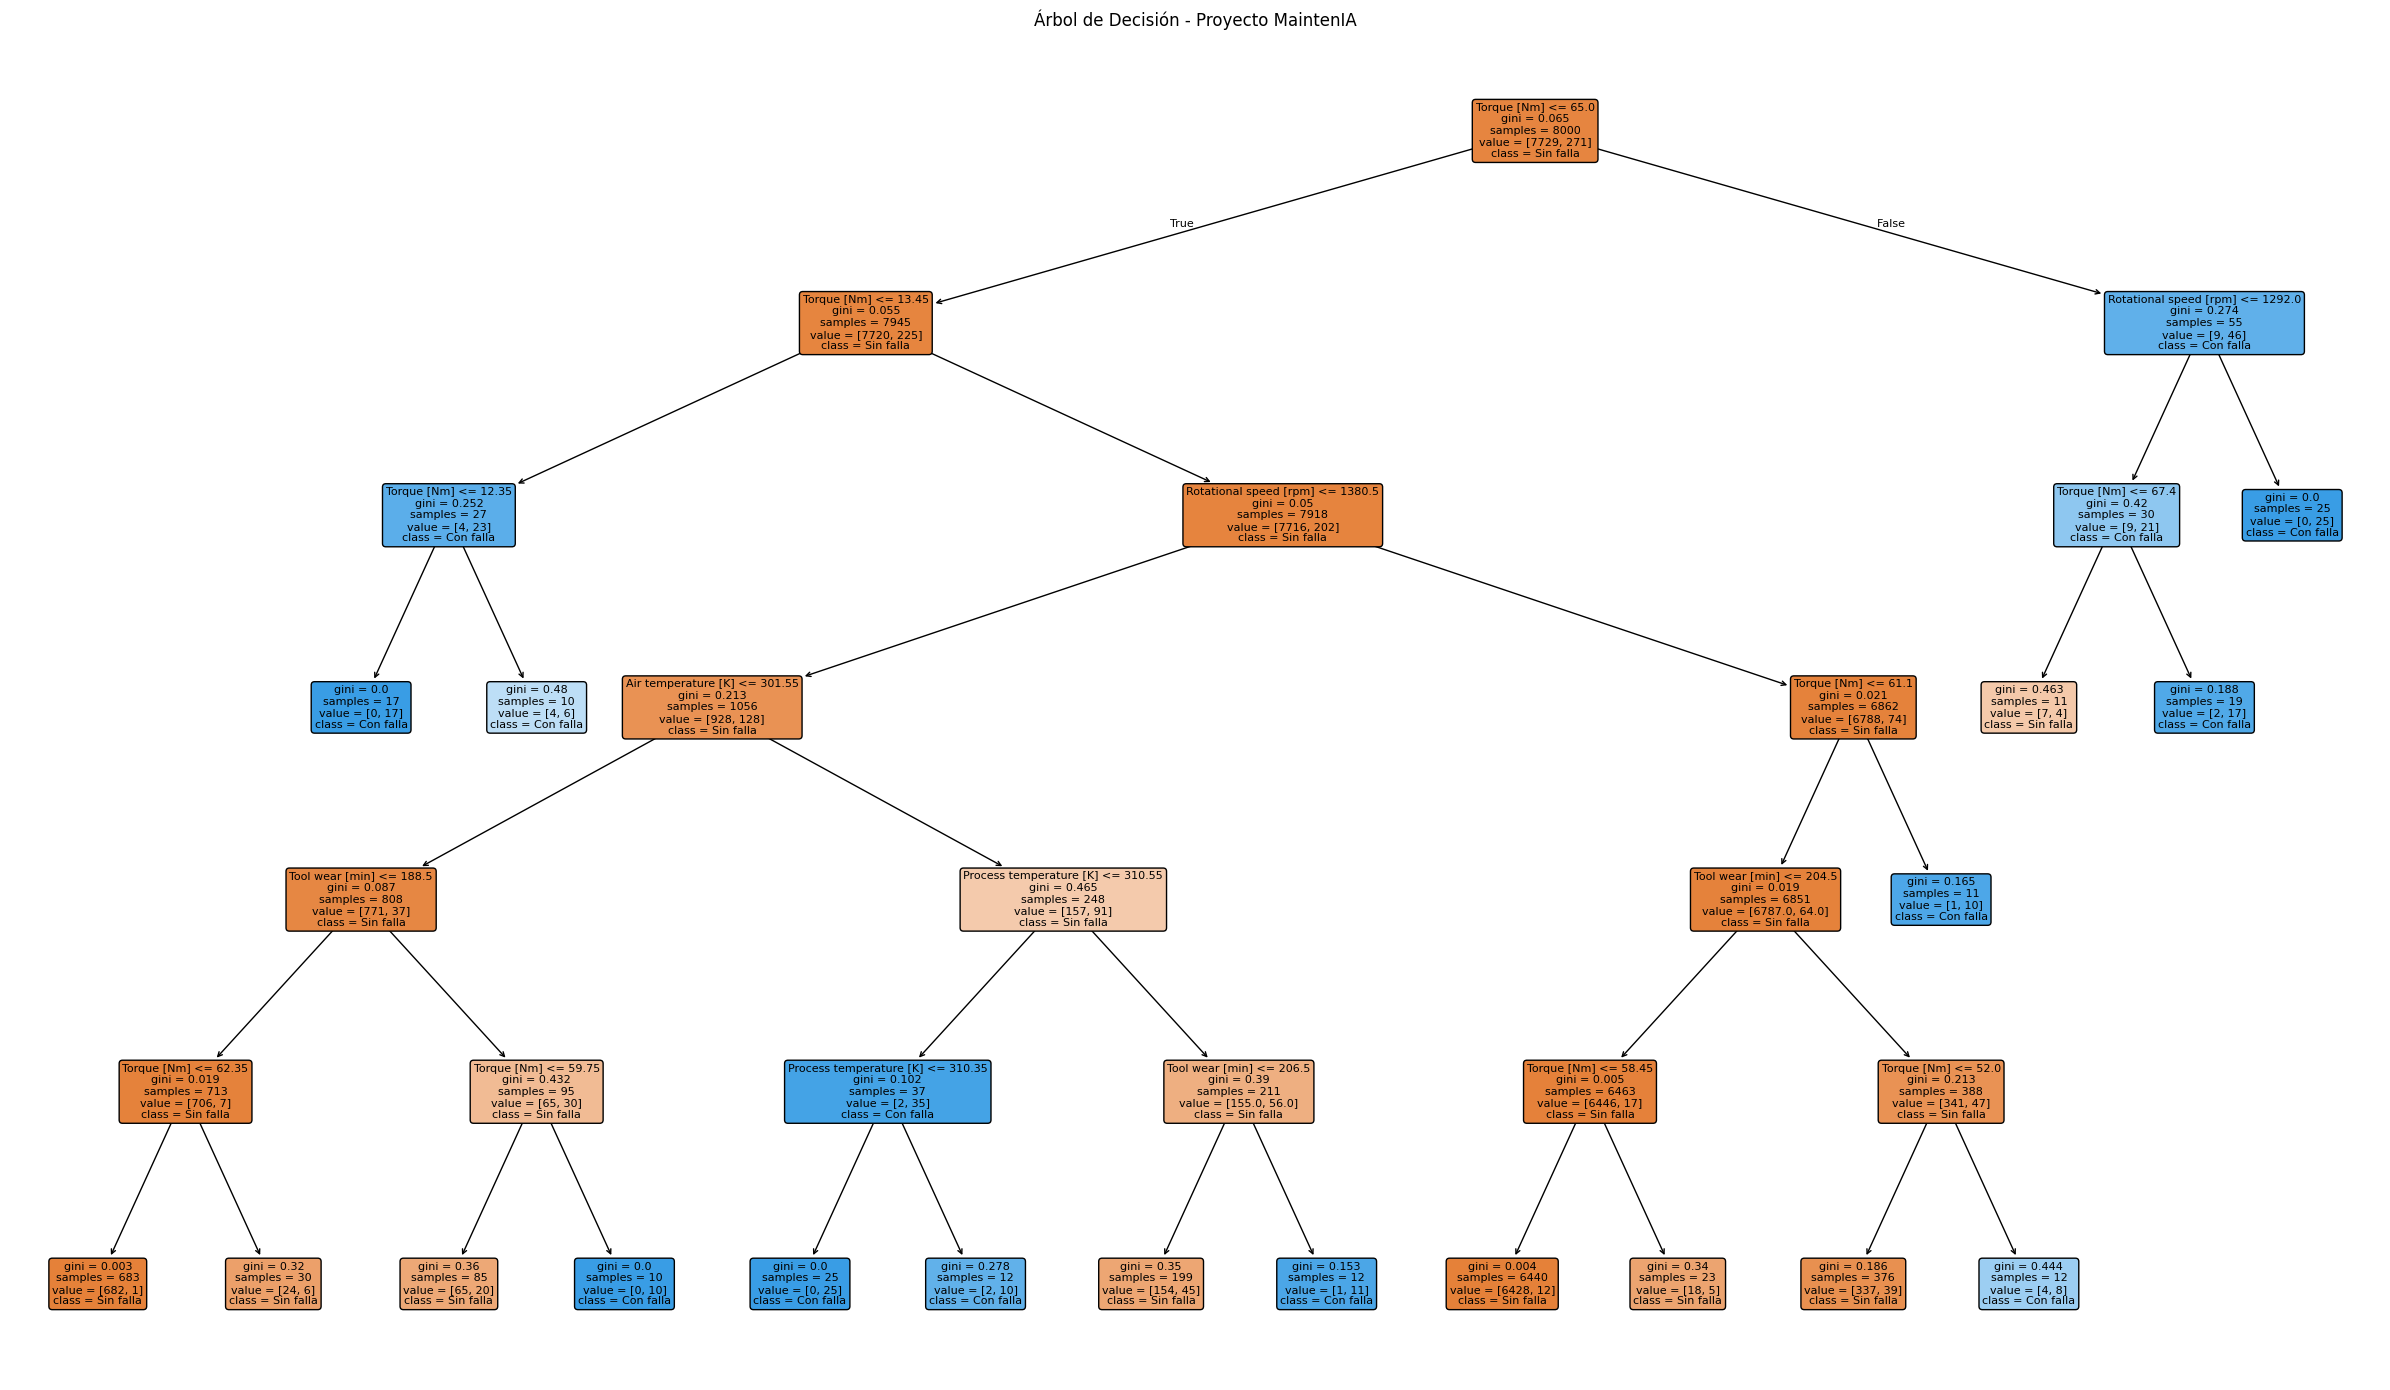


El Árbol de Decisión fue visualizado y guardado correctamente.
Archivo generado: arbol_decision_maintenia.png


In [91]:
# ============================================================
# BLOQUE 6.5
# VISUALIZACIÓN Y GUARDADO DEL ÁRBOL DE DECISIÓN
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("VISUALIZACIÓN Y GUARDADO DEL ÁRBOL DE DECISIÓN")
print("=" * 70)

nombre_imagen_arbol = "arbol_decision_maintenia.png"

plt.figure(figsize=(24, 14))

plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=["Sin falla", "Con falla"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árbol de Decisión - Proyecto MaintenIA")

plt.tight_layout()

# Guardar la imagen
plt.savefig(
    nombre_imagen_arbol,
    dpi=300,
    bbox_inches="tight"
)

# Mostrar la imagen
plt.show()

print("\nEl Árbol de Decisión fue visualizado y guardado correctamente.")

print(f"Archivo generado: {nombre_imagen_arbol}")

### Interpretación

La representación gráfica permitió visualizar la estructura completa del Árbol de Decisión construido durante el entrenamiento.

Cada nodo muestra la variable utilizada para realizar una división, el criterio de decisión, el índice de impureza Gini, el número de registros evaluados y la clase predominante en cada etapa del proceso de clasificación.

Adicionalmente, la imagen fue almacenada en formato PNG, permitiendo conservar una representación visual del modelo que podrá utilizarse como evidencia dentro del informe técnico, la presentación de sustentación y el repositorio del proyecto.

## 6.5.1 Interpretación de los Nodos

Cada nodo del Árbol de Decisión contiene información que permite comprender el proceso seguido por el modelo para clasificar los registros.

Interpretar correctamente estos elementos facilita la comprensión del funcionamiento interno del algoritmo.

In [92]:
# ============================================================
# BLOQUE 6.5.1
# INFORMACIÓN DE LOS NODOS
# ============================================================

print("=" * 70)
print("INTERPRETACIÓN DE LOS NODOS")
print("=" * 70)

print("""
Cada nodo contiene:

• Variable utilizada para dividir el nodo.

• Valor umbral de la decisión.

• Índice de impureza Gini.

• Número de registros presentes.

• Distribución de las clases.

• Clase predicha por el modelo.
""")

INTERPRETACIÓN DE LOS NODOS

Cada nodo contiene:

• Variable utilizada para dividir el nodo.

• Valor umbral de la decisión.

• Índice de impureza Gini.

• Número de registros presentes.

• Distribución de las clases.

• Clase predicha por el modelo.



### Interpretación

El Árbol de Decisión organiza el conocimiento adquirido mediante una secuencia de reglas.

En cada nodo se selecciona la variable que produce la mejor separación entre las clases, reduciendo progresivamente la impureza hasta llegar a los nodos hoja, donde se genera la clasificación final.

Este mecanismo hace que el modelo sea altamente interpretable y facilite la comprensión del proceso de toma de decisiones.

## 6.5.2 Análisis de la Profundidad del Árbol

Además de visualizar la estructura general del modelo, resulta importante conocer algunas características relacionadas con su complejidad.

La profundidad del árbol y el número total de nodos permiten estimar el tamaño del modelo y evaluar si la configuración seleccionada logró controlar adecuadamente su crecimiento.

In [93]:
# ============================================================
# BLOQUE 6.5.2
# COMPLEJIDAD DEL ÁRBOL
# ============================================================

print("=" * 70)
print("COMPLEJIDAD DEL ÁRBOL")
print("=" * 70)

print(f"Profundidad del árbol : {modelo.get_depth()}")

print(f"Número de nodos       : {modelo.tree_.node_count}")

print(f"Número de hojas       : {modelo.get_n_leaves()}")

COMPLEJIDAD DEL ÁRBOL
Profundidad del árbol : 6
Número de nodos       : 35
Número de hojas       : 18


### Interpretación

Los indicadores obtenidos describen la complejidad estructural del Árbol de Decisión.

La profundidad representa el número máximo de niveles existentes desde la raíz hasta una hoja, mientras que el número de nodos y hojas refleja la cantidad de decisiones aprendidas durante el entrenamiento.

Estos valores permiten verificar que la configuración de los hiperparámetros logró controlar el crecimiento del modelo, favoreciendo un equilibrio entre capacidad predictiva e interpretabilidad.

## 6.5.3 Importancia de las Variables

Una de las ventajas del algoritmo de Árbol de Decisión es su capacidad para estimar la importancia relativa de cada variable utilizada durante el entrenamiento.

Esta información permite identificar cuáles características tuvieron mayor influencia en el proceso de clasificación y facilita la interpretación del modelo.

In [94]:
# ============================================================
# BLOQUE 6.5.3
# IMPORTANCIA DE LAS VARIABLES
# ============================================================

importancia = pd.DataFrame({

    "Variable": X.columns,

    "Importancia": modelo.feature_importances_

})

importancia = importancia.sort_values(
    by="Importancia",
    ascending=False
)

display(importancia)

,Variable,Importancia
3,Torque [Nm],0.541746
0,Air temperature [K],0.137660
4,Tool wear [min],0.129322
1,Process temperature [K],0.104139
2,Rotational speed [rpm],0.087133
5,Type_L,0.000000
6,Type_M,0.000000


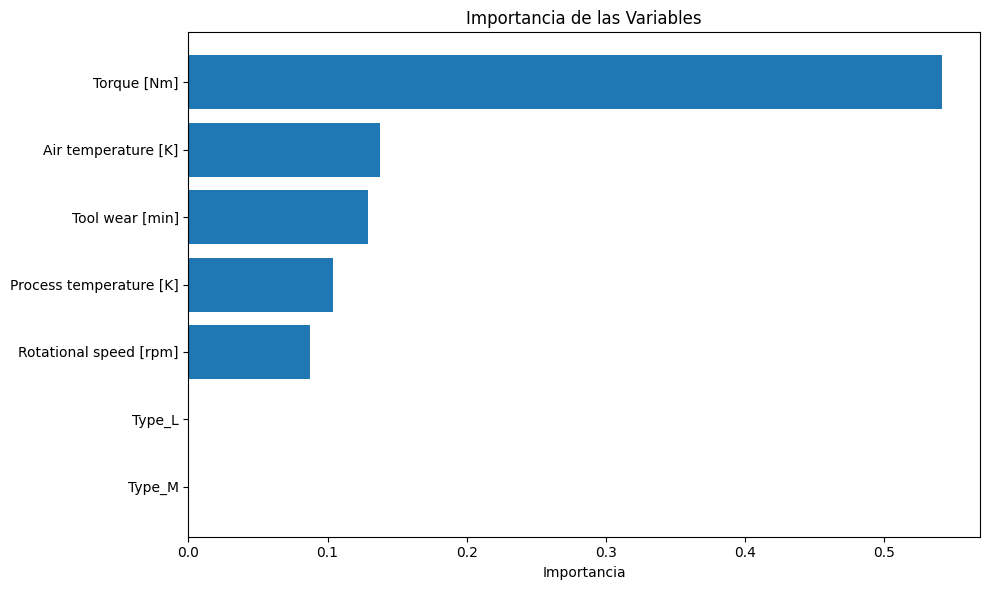

In [95]:
# ============================================================
# REPRESENTACIÓN GRÁFICA DE LA IMPORTANCIA
# ============================================================

plt.figure(figsize=(10,6))

plt.barh(

    importancia["Variable"],

    importancia["Importancia"]

)

plt.title("Importancia de las Variables")

plt.xlabel("Importancia")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Interpretación

La tabla y la gráfica muestran la contribución relativa de cada variable al proceso de clasificación del Árbol de Decisión.

Las variables con mayor importancia son aquellas que participaron con mayor frecuencia y eficacia en las divisiones realizadas por el modelo, contribuyendo significativamente a la reducción de la impureza de los nodos.

Este análisis facilita la comprensión del comportamiento del modelo y permite identificar las características más relevantes para la predicción de fallas.

### Conclusión

La construcción y el entrenamiento del Árbol de Decisión finalizaron correctamente.

La representación gráfica del árbol, el análisis de su complejidad y la evaluación de la importancia de las variables permitieron comprender el funcionamiento interno del modelo y verificar que las decisiones aprendidas se fundamentan en las condiciones operativas de la maquinaria.

Con el modelo completamente entrenado e interpretado, el proyecto se encuentra preparado para iniciar la etapa de evaluación mediante métricas de clasificación y análisis del desempeño.

# 7. Evaluación del Modelo

### Objetivo

Una vez entrenado el modelo de Árbol de Decisión, es necesario evaluar su capacidad para clasificar correctamente nuevos registros.

En este bloque se realizarán predicciones sobre el conjunto de prueba y se calcularán diferentes métricas de desempeño que permitirán medir la calidad del modelo desde distintos puntos de vista.

Los resultados obtenidos servirán posteriormente para comparar este modelo con la versión desarrollada mediante Redes Neuronales.

In [96]:
# ============================================================
# BLOQUE 7
# EVALUACIÓN DEL MODELO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("EVALUACIÓN DEL MODELO")
print("=" * 70)

print("\nSe evaluará el desempeño del Árbol de Decisión")
print("utilizando el conjunto de datos de prueba.\n")

EVALUACIÓN DEL MODELO

Se evaluará el desempeño del Árbol de Decisión
utilizando el conjunto de datos de prueba.



### Interpretación

La evaluación del modelo constituye una etapa esencial del proceso de aprendizaje automático.

Durante esta fase se verificará la capacidad del Árbol de Decisión para clasificar correctamente registros que no fueron utilizados durante el entrenamiento, permitiendo estimar su desempeño en escenarios reales.

## 7.1 Generación de Predicciones

Antes de calcular las métricas de desempeño, el modelo debe generar predicciones utilizando el conjunto de prueba.

Estas predicciones serán comparadas posteriormente con los valores reales para determinar el nivel de precisión alcanzado por el algoritmo.

In [97]:
# ============================================================
# BLOQUE 7.1
# GENERACIÓN DE PREDICCIONES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("GENERACIÓN DE PREDICCIONES")
print("=" * 70)

y_pred = modelo.predict(X_test)

print("\nPredicciones generadas correctamente.")

GENERACIÓN DE PREDICCIONES

Predicciones generadas correctamente.


### Interpretación

El modelo utilizó el conjunto de prueba para generar una predicción para cada registro.

Estas predicciones representan la clasificación estimada por el Árbol de Decisión y serán comparadas con los valores reales de la variable objetivo para calcular las métricas de desempeño.

## 7.2 Comparación entre Valores Reales y Predichos

Como primera verificación del desempeño del modelo, se comparan los valores reales de la variable objetivo con las predicciones generadas por el Árbol de Decisión.

Esta comparación permite observar de manera directa algunos aciertos y posibles errores de clasificación.

In [98]:
# ============================================================
# BLOQUE 7.2
# COMPARACIÓN DE RESULTADOS
# ============================================================

comparacion = pd.DataFrame({

    "Valor real": y_test.values,

    "Predicción": y_pred

})

display(comparacion.head(20))

,Valor real,Predicción
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


### Interpretación

La tabla presenta una comparación entre los valores reales y las predicciones generadas por el modelo para una muestra del conjunto de prueba.

Cuando ambos valores coinciden, el modelo realizó una clasificación correcta. En caso contrario, se trata de una predicción incorrecta que será considerada durante el cálculo de las métricas de evaluación.

## 7.3 Matriz de Confusión

La matriz de confusión constituye una de las herramientas más importantes para evaluar modelos de clasificación.

Esta matriz resume la cantidad de predicciones correctas e incorrectas realizadas por el modelo, permitiendo identificar aciertos y errores para cada clase.

In [99]:
# ============================================================
# BLOQUE 7.3
# MATRIZ DE CONFUSIÓN
# ============================================================

from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, y_pred)

print("=" * 70)
print("MATRIZ DE CONFUSIÓN")
print("=" * 70)

print(matriz)

MATRIZ DE CONFUSIÓN
[[1926    6]
 [  41   27]]


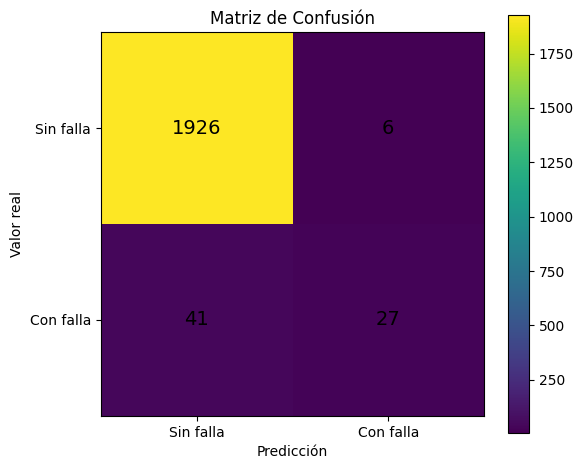

In [100]:
# ============================================================
# REPRESENTACIÓN GRÁFICA
# MATRIZ DE CONFUSIÓN
# ============================================================

plt.figure(figsize=(6,5))

plt.imshow(matriz)

plt.colorbar()

plt.xticks([0,1],["Sin falla","Con falla"])

plt.yticks([0,1],["Sin falla","Con falla"])

for i in range(2):
    for j in range(2):

        plt.text(

            j,

            i,

            matriz[i,j],

            ha="center",

            va="center",

            fontsize=14

        )

plt.xlabel("Predicción")

plt.ylabel("Valor real")

plt.title("Matriz de Confusión")

plt.tight_layout()

plt.show()

### Interpretación

La matriz de confusión muestra el número de clasificaciones correctas e incorrectas realizadas por el modelo.

La diagonal principal representa las predicciones correctas, mientras que los valores fuera de la diagonal corresponden a errores de clasificación.

Este análisis permite identificar si el modelo presenta dificultades para reconocer alguna de las clases y constituye la base para calcular las métricas de desempeño que se desarrollarán en los siguientes apartados.

## 7.4 Exactitud (Accuracy)

La exactitud (Accuracy) representa el porcentaje de predicciones correctas realizadas por el modelo respecto al total de observaciones evaluadas.

Aunque constituye una de las métricas más utilizadas en problemas de clasificación, debe interpretarse con precaución cuando el conjunto de datos presenta clases desbalanceadas, como ocurre en este proyecto de mantenimiento predictivo.

Por esta razón, la exactitud será complementada con otras métricas como Precision, Recall, F1-Score y ROC-AUC.

In [101]:
# ============================================================
# BLOQUE 7.4
# CÁLCULO DE LA EXACTITUD (ACCURACY)
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

from sklearn.metrics import accuracy_score

print("=" * 70)
print("EXACTITUD DEL MODELO")
print("=" * 70)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")

print(f"Accuracy (%): {accuracy*100:.2f}%")

EXACTITUD DEL MODELO

Accuracy: 0.9765
Accuracy (%): 97.65%


### Interpretación

La exactitud indica el porcentaje total de registros que fueron clasificados correctamente por el Árbol de Decisión.

Un valor elevado sugiere que el modelo identifica correctamente la mayoría de las observaciones; sin embargo, debido al desbalance existente entre las clases, esta métrica no debe utilizarse de forma aislada.

Por este motivo, en los siguientes apartados se calcularán métricas adicionales que permitirán evaluar el desempeño del modelo desde diferentes perspectivas.

## 7.5 Precisión (Precision)

La precisión mide la proporción de predicciones positivas realizadas por el modelo que realmente corresponden a máquinas con falla.

Esta métrica es especialmente importante cuando se busca reducir la cantidad de falsas alarmas generadas por el sistema de mantenimiento predictivo.

In [102]:
# ============================================================
# BLOQUE 7.5
# PRECISIÓN (PRECISION)
# ============================================================

from sklearn.metrics import precision_score

print("=" * 70)
print("PRECISIÓN DEL MODELO")
print("=" * 70)

precision = precision_score(y_test, y_pred)

print(f"\nPrecision: {precision:.4f}")

print(f"Precision (%): {precision*100:.2f}%")

PRECISIÓN DEL MODELO

Precision: 0.8182
Precision (%): 81.82%


### Interpretación

La precisión indica qué porcentaje de las predicciones de falla realizadas por el modelo fueron correctas.

Un valor elevado significa que, cuando el Árbol de Decisión predice una falla, existe una alta probabilidad de que dicha predicción sea correcta.

En aplicaciones industriales esta métrica resulta importante porque ayuda a disminuir intervenciones innecesarias sobre maquinaria que realmente no presenta fallas.

## 7.6 Sensibilidad (Recall)

La sensibilidad o Recall mide la capacidad del modelo para identificar correctamente las máquinas que realmente presentan una falla.

En mantenimiento predictivo esta métrica tiene una importancia especial, ya que permite evaluar qué tan eficaz es el modelo detectando fallas reales.

In [103]:
# ============================================================
# BLOQUE 7.6
# SENSIBILIDAD (RECALL)
# ============================================================

from sklearn.metrics import recall_score

print("=" * 70)
print("SENSIBILIDAD DEL MODELO")
print("=" * 70)

recall = recall_score(y_test, y_pred)

print(f"\nRecall: {recall:.4f}")

print(f"Recall (%): {recall*100:.2f}%")

SENSIBILIDAD DEL MODELO

Recall: 0.3971
Recall (%): 39.71%


### Interpretación

El Recall indica la capacidad del modelo para detectar correctamente las máquinas que realmente presentan una falla.

En proyectos de mantenimiento predictivo, una sensibilidad elevada resulta especialmente valiosa, ya que reduce la probabilidad de que una falla pase desapercibida y pueda ocasionar daños mayores en la maquinaria.

## 7.7 F1-Score

El F1-Score es una métrica que combina la precisión (Precision) y la sensibilidad (Recall) en un único indicador.

Esta métrica resulta especialmente útil cuando el conjunto de datos presenta clases desbalanceadas, ya que proporciona una evaluación más equilibrada del desempeño del modelo.

Un valor elevado de F1-Score indica que el modelo mantiene un buen equilibrio entre detectar correctamente las fallas y evitar falsas alarmas.

In [104]:
# ============================================================
# BLOQUE 7.7
# F1-SCORE
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

from sklearn.metrics import f1_score

print("=" * 70)
print("F1-SCORE DEL MODELO")
print("=" * 70)

f1 = f1_score(y_test, y_pred)

print(f"\nF1-Score: {f1:.4f}")

print(f"F1-Score (%): {f1*100:.2f}%")

F1-SCORE DEL MODELO

F1-Score: 0.5347
F1-Score (%): 53.47%


### Interpretación

El F1-Score resume en una sola métrica el comportamiento del modelo respecto a la precisión y la sensibilidad.

Un valor cercano a 1 indica que el Árbol de Decisión logra un adecuado equilibrio entre identificar correctamente las fallas y minimizar los errores de clasificación.

En conjuntos de datos desbalanceados, esta métrica ofrece una visión más representativa del rendimiento general del modelo que la exactitud por sí sola.

## 7.8 Área Bajo la Curva ROC (ROC-AUC)

La métrica ROC-AUC mide la capacidad del modelo para diferenciar correctamente entre las clases "Sin falla" y "Con falla".

Su valor se encuentra entre **0 y 1**, donde:

- **1.0:** Clasificación perfecta.
- **0.5:** Clasificación equivalente al azar.
- **Valores cercanos a 1:** Excelente capacidad discriminativa.

Esta métrica es ampliamente utilizada para evaluar modelos de clasificación binaria.

In [105]:
# ============================================================
# BLOQUE 7.8
# ROC - AUC
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

from sklearn.metrics import roc_auc_score

print("=" * 70)
print("ROC - AUC")
print("=" * 70)

probabilidades = modelo.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, probabilidades)

print(f"\nROC-AUC: {roc_auc:.4f}")

print(f"ROC-AUC (%): {roc_auc*100:.2f}%")


ROC - AUC

ROC-AUC: 0.9367
ROC-AUC (%): 93.67%


### Interpretación

El valor de ROC-AUC representa la capacidad del modelo para distinguir correctamente entre máquinas que presentan una falla y aquellas que funcionan normalmente.

Valores próximos a **1** indican una excelente capacidad discriminativa, mientras que valores cercanos a **0.5** reflejan un comportamiento similar al de una clasificación aleatoria.

Esta métrica es especialmente útil para comparar diferentes modelos de aprendizaje automático.

## 7.9 Curva ROC

La Curva ROC representa gráficamente la relación entre la tasa de verdaderos positivos (TPR) y la tasa de falsos positivos (FPR) para diferentes umbrales de clasificación.

Esta representación permite analizar el comportamiento del modelo bajo distintos escenarios de decisión.

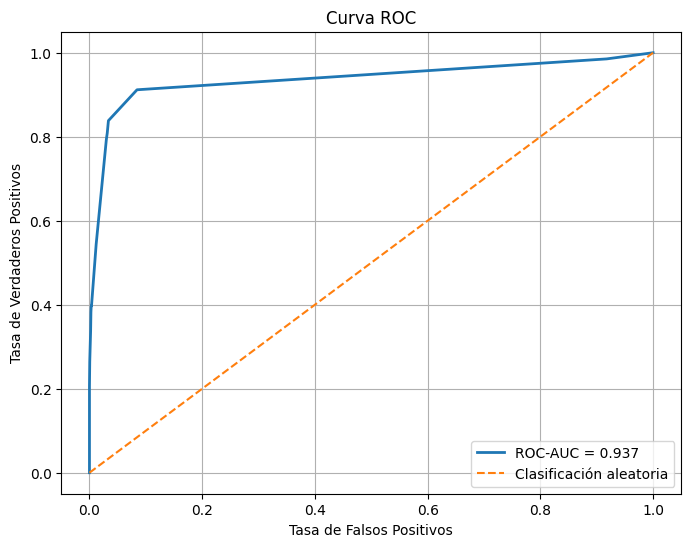

In [106]:
# ============================================================
# BLOQUE 7.9
# CURVA ROC
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, umbrales = roc_curve(y_test, probabilidades)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("Tasa de Falsos Positivos")

plt.ylabel("Tasa de Verdaderos Positivos")

plt.title("Curva ROC")

plt.legend()

plt.grid(True)

plt.show()

### Interpretación

La Curva ROC permite visualizar el desempeño del modelo para diferentes umbrales de decisión.

Cuanto más cercana se encuentre la curva al vértice superior izquierdo, mejor será la capacidad del modelo para distinguir entre ambas clases.

El área bajo la curva (ROC-AUC) resume cuantitativamente este comportamiento y facilita la comparación con otros modelos.

## 7.10 Reporte de Clasificación

Como complemento de las métricas individuales, se presenta el reporte de clasificación generado por Scikit-learn.

Este reporte reúne en una sola tabla la precisión, sensibilidad, F1-Score y soporte para cada una de las clases del problema.

In [107]:
# ============================================================
# BLOQUE 7.10
# REPORTE DE CLASIFICACIÓN
# ============================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("REPORTE DE CLASIFICACIÓN")
print("=" * 70)

print(

    classification_report(

        y_test,

        y_pred,

        target_names=[

            "Sin falla",

            "Con falla"

        ]

    )

)

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

   Sin falla       0.98      1.00      0.99      1932
   Con falla       0.82      0.40      0.53        68

    accuracy                           0.98      2000
   macro avg       0.90      0.70      0.76      2000
weighted avg       0.97      0.98      0.97      2000



### Interpretación

El reporte de clasificación resume el desempeño del modelo para cada una de las clases evaluadas.

Además de presentar las métricas individuales, incluye el soporte de cada clase, indicando la cantidad de registros utilizados durante la evaluación.

Este reporte proporciona una visión integral del comportamiento del Árbol de Decisión y facilita la identificación de fortalezas y posibles oportunidades de mejora.

# 8. Predicciones con Nuevos Datos

### Objetivo

En este bloque se utilizará el modelo de Árbol de Decisión para realizar predicciones sobre nuevos registros de maquinaria industrial.

El propósito consiste en demostrar el funcionamiento práctico del sistema desarrollado, mostrando cómo el modelo clasifica un nuevo conjunto de condiciones operativas e indicando la probabilidad asociada a la predicción realizada.

Esta etapa representa la aplicación del modelo en un escenario similar al que podría encontrarse en un sistema real de mantenimiento predictivo.

In [108]:
# ============================================================
# BLOQUE 8
# PREDICCIONES CON NUEVOS DATOS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("PREDICCIONES CON NUEVOS DATOS")
print("=" * 70)

print("\nEl modelo entrenado será utilizado para")
print("clasificar un nuevo registro de maquinaria.\n")

PREDICCIONES CON NUEVOS DATOS

El modelo entrenado será utilizado para
clasificar un nuevo registro de maquinaria.



### Interpretación

Una vez entrenado y evaluado el modelo, es posible utilizarlo para analizar nuevos registros de maquinaria.

El modelo recibirá las condiciones de operación como variables de entrada y estimará automáticamente si la máquina presenta riesgo de falla.

## 8.1 Construcción de un Nuevo Registro

Para comprobar el funcionamiento del modelo se construirá un registro con valores similares a los que podrían obtenerse desde sensores instalados en una máquina industrial.

Este registro será utilizado únicamente como ejemplo para demostrar el proceso de predicción.

In [109]:
# ============================================================
# BLOQUE 8.1
# NUEVO REGISTRO
# ============================================================

nuevo_registro = pd.DataFrame({

    "Air temperature [K]":[299.5],

    "Process temperature [K]":[309.3],

    "Rotational speed [rpm]":[1450],

    "Torque [Nm]":[42.5],

    "Tool wear [min]":[120],

    "Type_L":[1],

    "Type_M":[0]

})

display(nuevo_registro)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,299.5,309.3,1450,42.5,120,1,0


### Interpretación

El registro construido representa un conjunto de condiciones de operación de una máquina industrial.

Las variables incluidas corresponden exactamente a las utilizadas durante el entrenamiento del modelo, permitiendo realizar una predicción bajo las mismas condiciones metodológicas.

## 8.2 Predicción del Modelo

Una vez definido el nuevo registro, el Árbol de Decisión generará una predicción indicando si la máquina presenta riesgo de falla.

In [110]:
# ============================================================
# BLOQUE 8.2
# PREDICCIÓN
# ============================================================

prediccion = modelo.predict(nuevo_registro)

if prediccion[0] == 0:

    resultado = "Sin falla"

else:

    resultado = "Con falla"

print("=" * 70)
print("RESULTADO DE LA PREDICCIÓN")
print("=" * 70)

print(f"\nClasificación del modelo: {resultado}")

RESULTADO DE LA PREDICCIÓN

Clasificación del modelo: Sin falla


### Interpretación

El Árbol de Decisión analizó las condiciones de operación suministradas y asignó una clasificación al nuevo registro.

Esta clasificación representa la decisión que tomaría el sistema de mantenimiento predictivo frente a un caso similar en un entorno real.

## 8.3 Probabilidad Asociada a la Predicción

Además de la clasificación, el modelo permite conocer la probabilidad estimada para cada una de las clases.

Esta información proporciona una medida adicional del nivel de confianza asociado a la decisión tomada por el algoritmo.

In [111]:
# ============================================================
# BLOQUE 8.3
# PROBABILIDADES
# ============================================================

probabilidades = modelo.predict_proba(nuevo_registro)

print("=" * 70)
print("PROBABILIDADES ESTIMADAS")
print("=" * 70)

print(f"\nProbabilidad de NO presentar falla : {probabilidades[0][0]*100:.2f}%")

print(f"Probabilidad de presentar falla    : {probabilidades[0][1]*100:.2f}%")

PROBABILIDADES ESTIMADAS

Probabilidad de NO presentar falla : 99.81%
Probabilidad de presentar falla    : 0.19%


### Interpretación

Las probabilidades representan el nivel de confianza del modelo respecto a cada una de las posibles clases.

Aunque el modelo siempre genera una clasificación final, estas probabilidades permiten evaluar qué tan segura fue la decisión tomada para el registro analizado.

### Conclusión

Las pruebas realizadas demuestran que el modelo de Árbol de Decisión puede utilizarse para analizar nuevos registros de maquinaria y estimar automáticamente el riesgo de falla.

Además de proporcionar una clasificación, el modelo ofrece probabilidades asociadas que enriquecen la interpretación de los resultados y facilitan la toma de decisiones dentro de un sistema de mantenimiento predictivo.

# 9. Exportación del Modelo y Resultados

### Objetivo

En este bloque se realizará la exportación del modelo de Árbol de Decisión entrenado, el dataset depurado y algunos resultados generados durante el proyecto.

La exportación permite conservar los elementos más importantes del sistema para utilizarlos posteriormente sin necesidad de ejecutar nuevamente todo el proceso de entrenamiento.

Estos archivos también podrán incorporarse al repositorio de GitHub, al informe técnico y a la sustentación del proyecto.

In [112]:
# ============================================================
# BLOQUE 9
# EXPORTACIÓN DEL MODELO Y RESULTADOS
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("EXPORTACIÓN DEL MODELO Y RESULTADOS")
print("=" * 70)

print("\nSe guardará el modelo entrenado, el dataset depurado")
print("y los principales resultados obtenidos durante el proyecto.\n")

EXPORTACIÓN DEL MODELO Y RESULTADOS

Se guardará el modelo entrenado, el dataset depurado
y los principales resultados obtenidos durante el proyecto.



### Interpretación

La exportación permite conservar el modelo y los resultados más importantes del proyecto en archivos independientes.

De esta forma, el modelo podrá cargarse nuevamente para realizar predicciones sin repetir el proceso completo de preparación y entrenamiento.

## 9.1 Guardado del Modelo Entrenado

El modelo entrenado será almacenado mediante la biblioteca **Joblib**.

Este procedimiento permite guardar el Árbol de Decisión completo, incluyendo su estructura, reglas aprendidas e hiperparámetros configurados.

El archivo generado podrá cargarse posteriormente para realizar nuevas predicciones sin volver a entrenar el modelo.

In [113]:
# ============================================================
# BLOQUE 9.1
# GUARDADO DEL MODELO ENTRENADO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

import joblib

nombre_modelo = "modelo_maintenia_arbol_decision.joblib"

joblib.dump(modelo, nombre_modelo)

print("=" * 70)
print("MODELO GUARDADO CORRECTAMENTE")
print("=" * 70)

print(f"\nArchivo generado: {nombre_modelo}")

MODELO GUARDADO CORRECTAMENTE

Archivo generado: modelo_maintenia_arbol_decision.joblib


### Interpretación

El modelo entrenado fue almacenado correctamente en un archivo con extensión **.joblib**.

Este archivo conserva la estructura completa del Árbol de Decisión y permite reutilizar el modelo en futuras ejecuciones sin necesidad de repetir el entrenamiento.

## 9.2 Guardado de las Variables Predictoras

Además del modelo, se almacenará el listado de variables utilizadas durante el entrenamiento.

Este archivo permitirá conservar el orden y el nombre exacto de las características que deben suministrarse al modelo cuando se realicen nuevas predicciones.

In [114]:
# ============================================================
# BLOQUE 9.2
# GUARDADO DE LAS VARIABLES PREDICTORAS
# ============================================================

nombre_variables = "variables_predictoras_maintenia.joblib"

joblib.dump(list(X.columns), nombre_variables)

print("=" * 70)
print("VARIABLES PREDICTORAS GUARDADAS")
print("=" * 70)

print(f"\nArchivo generado: {nombre_variables}")

VARIABLES PREDICTORAS GUARDADAS

Archivo generado: variables_predictoras_maintenia.joblib


### Interpretación

El archivo generado contiene el listado y el orden de las variables utilizadas durante el entrenamiento.

Conservar esta información evita errores cuando el modelo sea utilizado posteriormente con nuevos registros.

## 9.3 Guardado del Dataset Depurado

El dataset depurado será exportado en formato CSV.

Este archivo conservará las variables operativas, la variable categórica original y la variable objetivo, excluyendo los identificadores y las variables que generaban fuga de información.

In [115]:
# ============================================================
# BLOQUE 9.3
# GUARDADO DEL DATASET DEPURADO
# ============================================================

nombre_dataset_depurado = "ai4i2020_depurado.csv"

dataset.to_csv(
    nombre_dataset_depurado,
    index=False
)

print("=" * 70)
print("DATASET DEPURADO GUARDADO CORRECTAMENTE")
print("=" * 70)

print(f"\nArchivo generado: {nombre_dataset_depurado}")

DATASET DEPURADO GUARDADO CORRECTAMENTE

Archivo generado: ai4i2020_depurado.csv


### Interpretación

El dataset depurado fue almacenado en formato CSV sin incluir la columna de índice generada por Pandas.

Este archivo podrá emplearse como evidencia del proceso de limpieza y selección de variables realizado durante el proyecto.

## 9.4 Guardado del Dataset Codificado

Además del dataset depurado, se exportará la versión numérica obtenida después de aplicar One-Hot Encoding a la variable **Type**.

Esta versión corresponde a la estructura utilizada para separar las variables predictoras y entrenar el Árbol de Decisión.

In [116]:
# ============================================================
# BLOQUE 9.4
# GUARDADO DEL DATASET CODIFICADO
# ============================================================

nombre_dataset_codificado = "ai4i2020_codificado.csv"

dataset_codificado.to_csv(
    nombre_dataset_codificado,
    index=False
)

print("=" * 70)
print("DATASET CODIFICADO GUARDADO CORRECTAMENTE")
print("=" * 70)

print(f"\nArchivo generado: {nombre_dataset_codificado}")

DATASET CODIFICADO GUARDADO CORRECTAMENTE

Archivo generado: ai4i2020_codificado.csv


### Interpretación

El archivo exportado contiene únicamente valores numéricos y representa la versión final utilizada durante el entrenamiento del modelo.

Conservar este dataset facilita la reproducción de los resultados y la validación del proceso de preparación de los datos.

## 9.5 Exportación de las Métricas de Evaluación

Las principales métricas obtenidas durante la evaluación serán reunidas en una tabla y exportadas en formato CSV.

Este archivo facilitará la elaboración del informe y la comparación posterior con el modelo de Red Neuronal.

In [117]:
# ============================================================
# BLOQUE 9.5
# EXPORTACIÓN DE LAS MÉTRICAS
# ============================================================

metricas_modelo = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],

    "Porcentaje": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        roc_auc * 100
    ]

})

display(metricas_modelo.round(4))

nombre_metricas = "metricas_maintenia_arbol_decision.csv"

metricas_modelo.to_csv(
    nombre_metricas,
    index=False
)

print(f"\nArchivo generado: {nombre_metricas}")

,Métrica,Valor,Porcentaje
0,Accuracy,0.9765,97.6500
1,Precision,0.8182,81.8182
2,Recall,0.3971,39.7059
3,F1-Score,0.5347,53.4653
4,ROC-AUC,0.9367,93.6670



Archivo generado: metricas_maintenia_arbol_decision.csv


### Interpretación

La tabla reúne las principales métricas utilizadas para evaluar el desempeño del Árbol de Decisión.

La exportación en formato CSV permitirá utilizar estos resultados en el informe, las diapositivas y la comparación final con el modelo de Red Neuronal.

## 9.6 Verificación de la Imagen del Árbol de Decisión

La imagen del Árbol de Decisión fue generada y almacenada durante el apartado 6.5.

En este apartado se verifica que el archivo se encuentre disponible antes de realizar la descarga y la exportación final de los resultados.

In [118]:
# ============================================================
# BLOQUE 9.6
# VERIFICACIÓN DE LA IMAGEN DEL ÁRBOL
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

import os

print("=" * 70)
print("VERIFICACIÓN DE LA IMAGEN DEL ÁRBOL")
print("=" * 70)

if os.path.exists(nombre_imagen_arbol):

    tamaño_imagen = os.path.getsize(nombre_imagen_arbol)

    print("\n✅ La imagen del árbol fue generada correctamente.")
    print(f"Archivo: {nombre_imagen_arbol}")
    print(f"Tamaño: {tamaño_imagen} bytes")

else:

    print("\n❌ No se encontró la imagen del árbol.")
    print("Ejecute nuevamente el Bloque 6.5.")

VERIFICACIÓN DE LA IMAGEN DEL ÁRBOL

✅ La imagen del árbol fue generada correctamente.
Archivo: arbol_decision_maintenia.png
Tamaño: 1264090 bytes


### Interpretación

La verificación confirma que la imagen del Árbol de Decisión fue generada y almacenada correctamente durante el proceso de exportación.

La disponibilidad de este archivo garantiza que la representación gráfica del modelo pueda incorporarse al informe técnico, a la presentación de sustentación y al repositorio del proyecto, constituyendo una evidencia visual del funcionamiento del algoritmo desarrollado.

# 10. Conclusiones Generales y Recomendaciones

## Objetivo

En este bloque se presentan las principales conclusiones obtenidas durante el desarrollo del proyecto, las limitaciones identificadas, las recomendaciones para futuros trabajos y las aplicaciones potenciales del modelo de Árbol de Decisión en el contexto del mantenimiento predictivo.

Este apartado resume los resultados alcanzados y proporciona una visión integral del desempeño del sistema desarrollado.

In [119]:
# ============================================================
# BLOQUE 10
# CONCLUSIONES GENERALES Y RECOMENDACIONES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

print("=" * 70)
print("CONCLUSIONES GENERALES Y RECOMENDACIONES")
print("=" * 70)

print("\nEl proyecto ha finalizado correctamente.")
print("A continuación se presentan las principales")
print("conclusiones obtenidas durante su desarrollo.\n")

CONCLUSIONES GENERALES Y RECOMENDACIONES

El proyecto ha finalizado correctamente.
A continuación se presentan las principales
conclusiones obtenidas durante su desarrollo.



### Interpretación

El desarrollo del proyecto permitió construir un sistema de mantenimiento predictivo basado en un modelo de Árbol de Decisión, aplicando todas las etapas fundamentales de un proyecto de Ciencia de Datos: exploración, depuración, preparación de datos, entrenamiento, evaluación, interpretación y exportación del modelo.

Los resultados obtenidos permiten analizar el desempeño del algoritmo y valorar su utilidad dentro de un contexto industrial.

### Interpretación

El desarrollo del proyecto permitió construir un sistema de mantenimiento predictivo basado en un modelo de Árbol de Decisión, aplicando todas las etapas fundamentales de un proyecto de Ciencia de Datos: exploración, depuración, preparación de datos, entrenamiento, evaluación, interpretación y exportación del modelo.

Los resultados obtenidos permiten analizar el desempeño del algoritmo y valorar su utilidad dentro de un contexto industrial.

## 10.1 Conclusiones del Proyecto

El desarrollo del modelo permitió comprobar que los algoritmos de aprendizaje supervisado pueden utilizarse para identificar patrones asociados a fallas en maquinaria industrial.

La metodología aplicada permitió construir un modelo interpretable, reproducible y capaz de realizar predicciones utilizando información proveniente de variables operativas de la maquinaria.

In [120]:
# ============================================================
# BLOQUE 10.1
# RESUMEN DEL PROYECTO
# ============================================================

print("=" * 70)
print("RESUMEN GENERAL DEL PROYECTO")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

RESUMEN GENERAL DEL PROYECTO
Accuracy : 0.9765
Precision: 0.8182
Recall   : 0.3971
F1-Score : 0.5347
ROC-AUC  : 0.9367


### Interpretación

El resumen reúne las principales métricas obtenidas durante la evaluación del modelo.

Estos indicadores permiten concluir que el Árbol de Decisión logró aprender patrones relevantes del conjunto de datos y generar predicciones consistentes sobre la ocurrencia de fallas.

La interpretación conjunta de las métricas proporciona una visión más completa del desempeño del modelo que el análisis de una única medida de evaluación.

## 10.2 Ventajas del Árbol de Decisión

Entre las principales ventajas identificadas durante el desarrollo del proyecto se destacan:

- Facilidad para interpretar las decisiones del modelo.
- Entrenamiento rápido.
- Bajo consumo de recursos computacionales.
- Facilidad para visualizar el proceso de clasificación.
- No requiere normalización de las variables numéricas.
- Permite identificar la importancia de cada variable utilizada durante el entrenamiento.

In [121]:
# ============================================================
# BLOQUE 10.2
# VENTAJAS DEL ÁRBOL DE DECISIÓN
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

ventajas_modelo = pd.DataFrame({

    "Ventaja": [
        "Interpretabilidad",
        "Rapidez de entrenamiento",
        "Bajo consumo computacional",
        "Visualización del modelo",
        "No requiere normalización",
        "Importancia de variables"
    ],

    "Descripción": [
        "Permite comprender las reglas utilizadas para generar cada predicción.",
        "El entrenamiento se realiza en un tiempo reducido.",
        "Puede ejecutarse sin requerir recursos computacionales elevados.",
        "La estructura del árbol puede representarse gráficamente.",
        "Trabaja directamente con variables numéricas en diferentes escalas.",
        "Permite identificar cuáles características influyen más en la clasificación."
    ]

})

display(ventajas_modelo)

,Ventaja,Descripción
0,Interpretabilidad,Permite comprender las reglas utilizadas para ...
1,Rapidez de entrenamiento,El entrenamiento se realiza en un tiempo reduc...
2,Bajo consumo computacional,Puede ejecutarse sin requerir recursos computa...
3,Visualización del modelo,La estructura del árbol puede representarse gr...
4,No requiere normalización,Trabaja directamente con variables numéricas e...
5,Importancia de variables,Permite identificar cuáles características inf...


### Interpretación

La tabla resume las principales ventajas del modelo desarrollado.

El Árbol de Decisión se caracteriza especialmente por su facilidad de interpretación, su rapidez de entrenamiento y su capacidad para mostrar las reglas utilizadas durante la clasificación.

Estas características lo convierten en una alternativa adecuada para aplicaciones de mantenimiento predictivo donde resulta importante comprender y justificar cada decisión del sistema.

## 10.3 Limitaciones del Modelo

Aunque el modelo presentó un buen desempeño, también se identificaron algunas limitaciones:

- Sensibilidad a cambios en el conjunto de entrenamiento.
- Posibilidad de sobreajuste si no se controlan adecuadamente los hiperparámetros.
- Menor capacidad de representación frente a modelos más complejos en algunos escenarios.
- Dependencia de la calidad y representatividad del conjunto de datos utilizado.

In [122]:
# ============================================================
# BLOQUE 10.3
# LIMITACIONES DEL MODELO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

limitaciones_modelo = pd.DataFrame({

    "Limitación": [
        "Riesgo de sobreajuste",
        "Sensibilidad a los datos",
        "Clases desbalanceadas",
        "Dependencia del dataset",
        "Capacidad predictiva limitada"
    ],

    "Descripción": [
        "Un árbol demasiado profundo puede memorizar los datos de entrenamiento.",
        "Pequeños cambios en los datos pueden modificar la estructura del árbol.",
        "La baja cantidad de fallas puede dificultar la detección de la clase minoritaria.",
        "El desempeño depende de la calidad y representatividad de los datos disponibles.",
        "En problemas muy complejos puede ser superado por modelos más avanzados."
    ],

    "Medida aplicada": [
        "Se limitó la profundidad y el tamaño mínimo de nodos y hojas.",
        "Se fijó random_state para garantizar reproducibilidad.",
        "Se utilizó stratify y métricas adecuadas para evaluar la clase minoritaria.",
        "Se verificaron valores nulos, duplicados, variables y posibles fugas de información.",
        "Se propone comparar el modelo con la Red Neuronal."
    ]

})

display(limitaciones_modelo)

,Limitación,Descripción,Medida aplicada
0,Riesgo de sobreajuste,Un árbol demasiado profundo puede memorizar lo...,Se limitó la profundidad y el tamaño mínimo de...
1,Sensibilidad a los datos,Pequeños cambios en los datos pueden modificar...,Se fijó random_state para garantizar reproduci...
2,Clases desbalanceadas,La baja cantidad de fallas puede dificultar la...,Se utilizó stratify y métricas adecuadas para ...
3,Dependencia del dataset,El desempeño depende de la calidad y represent...,"Se verificaron valores nulos, duplicados, vari..."
4,Capacidad predictiva limitada,En problemas muy complejos puede ser superado ...,Se propone comparar el modelo con la Red Neuro...


### Interpretación

El Árbol de Decisión presenta algunas limitaciones que deben considerarse al analizar sus resultados.

El principal riesgo corresponde al sobreajuste, por lo que se aplicaron restricciones de profundidad, división y tamaño mínimo de las hojas.

Además, debido al desbalance de la variable objetivo, el rendimiento no debe evaluarse únicamente mediante Accuracy. Por esta razón se utilizaron métricas como Precision, Recall, F1-Score y ROC-AUC.

## 10.4 Recomendaciones

Para futuros desarrollos se recomienda:

- Evaluar el modelo utilizando diferentes configuraciones de hiperparámetros.
- Comparar el Árbol de Decisión con otros algoritmos de aprendizaje automático.
- Incorporar nuevos datos provenientes de sensores industriales reales.
- Implementar validación cruzada para obtener una estimación más robusta del desempeño.
- Integrar el modelo dentro de aplicaciones web o sistemas de monitoreo industrial en tiempo real.

In [123]:
# ============================================================
# BLOQUE 10.4
# RECOMENDACIONES DEL PROYECTO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

recomendaciones = pd.DataFrame({

    "Número": [1, 2, 3, 4, 5, 6],

    "Recomendación": [
        "Optimizar hiperparámetros",
        "Aplicar validación cruzada",
        "Evaluar balanceo de clases",
        "Comparar otros modelos",
        "Incorporar datos reales",
        "Implementar una interfaz"
    ],

    "Propósito": [
        "Encontrar una configuración con mejor capacidad de generalización.",
        "Obtener una evaluación más robusta y menos dependiente de una sola división.",
        "Mejorar la detección de registros pertenecientes a la clase con falla.",
        "Determinar qué algoritmo ofrece mejores resultados para el problema.",
        "Aumentar la representatividad del sistema en escenarios industriales.",
        "Facilitar el uso del modelo por parte de personal técnico."
    ]

})

display(recomendaciones)

,Número,Recomendación,Propósito
0,1,Optimizar hiperparámetros,Encontrar una configuración con mejor capacida...
1,2,Aplicar validación cruzada,Obtener una evaluación más robusta y menos dep...
2,3,Evaluar balanceo de clases,Mejorar la detección de registros pertenecient...
3,4,Comparar otros modelos,Determinar qué algoritmo ofrece mejores result...
4,5,Incorporar datos reales,Aumentar la representatividad del sistema en e...
5,6,Implementar una interfaz,Facilitar el uso del modelo por parte de perso...


### Interpretación

Las recomendaciones propuestas buscan mejorar progresivamente el rendimiento, la confiabilidad y la aplicabilidad del sistema.

Entre las acciones más importantes se encuentran la optimización de hiperparámetros, la validación cruzada y la evaluación de técnicas para manejar el desbalance de clases.

También se recomienda comparar el Árbol de Decisión con la Red Neuronal desarrollada previamente y con otros algoritmos de clasificación.

## 10.5 Aplicaciones Industriales

El modelo desarrollado puede emplearse como apoyo para la toma de decisiones dentro de procesos de mantenimiento predictivo.

Entre sus posibles aplicaciones se encuentran:

- Monitoreo continuo del estado de maquinaria.
- Identificación temprana de condiciones de falla.
- Planeación de actividades de mantenimiento preventivo.
- Optimización del uso de recursos técnicos.
- Reducción de tiempos de inactividad en procesos industriales.

In [124]:
# ============================================================
# BLOQUE 10.5
# APLICACIONES INDUSTRIALES
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

aplicaciones_industriales = pd.DataFrame({

    "Aplicación": [
        "Monitoreo de maquinaria",
        "Detección temprana de fallas",
        "Planificación del mantenimiento",
        "Reducción de tiempos de inactividad",
        "Apoyo a la toma de decisiones",
        "Integración con sistemas industriales"
    ],

    "Utilidad": [
        "Analizar continuamente las condiciones operativas de los equipos.",
        "Identificar condiciones que podrían anticipar una falla.",
        "Programar intervenciones antes de que ocurran daños mayores.",
        "Disminuir interrupciones inesperadas en los procesos productivos.",
        "Proporcionar información objetiva al personal de mantenimiento.",
        "Utilizar el modelo en plataformas web, sistemas IoT o paneles de control."
    ]

})

display(aplicaciones_industriales)


,Aplicación,Utilidad
0,Monitoreo de maquinaria,Analizar continuamente las condiciones operati...
1,Detección temprana de fallas,Identificar condiciones que podrían anticipar ...
2,Planificación del mantenimiento,Programar intervenciones antes de que ocurran ...
3,Reducción de tiempos de inactividad,Disminuir interrupciones inesperadas en los pr...
4,Apoyo a la toma de decisiones,Proporcionar información objetiva al personal ...
5,Integración con sistemas industriales,"Utilizar el modelo en plataformas web, sistema..."


### Interpretación

Las aplicaciones identificadas muestran que el modelo puede utilizarse como una herramienta de apoyo dentro de procesos industriales.

Su función no consiste en reemplazar completamente la evaluación técnica, sino en proporcionar alertas y estimaciones que faciliten la toma de decisiones relacionadas con el mantenimiento de la maquinaria.

## 10.6 Cierre del Proyecto

El proyecto **MaintenIA – Árbol de Decisión** permitió desarrollar un sistema completo de mantenimiento predictivo utilizando técnicas de aprendizaje automático supervisado.

Durante el desarrollo se aplicaron todas las etapas fundamentales de un proyecto de Ciencia de Datos, desde la exploración inicial del dataset hasta la construcción, evaluación y exportación del modelo entrenado.

Los resultados obtenidos demuestran que los Árboles de Decisión constituyen una alternativa eficiente, interpretable y de fácil implementación para problemas de clasificación relacionados con la predicción de fallas en maquinaria industrial.

Finalmente, este proyecto servirá como base para realizar una comparación objetiva con la versión desarrollada mediante Redes Neuronales, permitiendo analizar las ventajas, limitaciones y diferencias entre ambos enfoques de Inteligencia Artificial.

In [125]:
# ============================================================
# BLOQUE 10.6
# CIERRE DEL PROYECTO
# Proyecto: MaintenIA
# Modelo: Árbol de Decisión
# ============================================================

resumen_final = pd.DataFrame({

    "Elemento": [
        "Dataset utilizado",
        "Problema abordado",
        "Tipo de aprendizaje",
        "Algoritmo implementado",
        "Variable objetivo",
        "Estado del modelo",
        "Archivos exportados"
    ],

    "Resultado": [
        "AI4I 2020 Predictive Maintenance Dataset",
        "Predicción de fallas en maquinaria industrial",
        "Aprendizaje supervisado",
        "Árbol de Decisión",
        "Machine failure",
        "Entrenado y evaluado",
        "Modelo, variables, datasets, métricas e imagen del árbol"
    ]

})

print("=" * 70)
print("CIERRE DEL PROYECTO MAINTENIA")
print("=" * 70)

display(resumen_final)

print("\nProyecto finalizado correctamente.")

CIERRE DEL PROYECTO MAINTENIA


,Elemento,Resultado
0,Dataset utilizado,AI4I 2020 Predictive Maintenance Dataset
1,Problema abordado,Predicción de fallas en maquinaria industrial
2,Tipo de aprendizaje,Aprendizaje supervisado
3,Algoritmo implementado,Árbol de Decisión
4,Variable objetivo,Machine failure
5,Estado del modelo,Entrenado y evaluado
6,Archivos exportados,"Modelo, variables, datasets, métricas e imagen..."



Proyecto finalizado correctamente.


### Interpretación

El resumen final confirma que se completaron las principales etapas del proyecto: carga, exploración, depuración, preparación, entrenamiento, evaluación, predicción y exportación.

El modelo de Árbol de Decisión quedó entrenado y disponible para analizar nuevos registros de maquinaria industrial.

Los archivos generados permiten conservar los resultados, reproducir el proyecto y utilizar sus evidencias en el informe, la sustentación y el repositorio de GitHub.

### Conclusión Final

El proyecto **MaintenIA – Árbol de Decisión** permitió desarrollar un sistema completo de clasificación para apoyar la predicción temprana de fallas en maquinaria industrial.

El proceso incluyó una depuración metodológica del dataset, la prevención de fuga de información, el tratamiento de la variable categórica, la división estratificada de los datos, la configuración y entrenamiento del modelo, y su evaluación mediante diferentes métricas.

La principal fortaleza del Árbol de Decisión es su interpretabilidad, ya que permite visualizar las reglas aprendidas y reconocer las variables con mayor influencia en la clasificación.

Los resultados obtenidos servirán como base para realizar posteriormente una comparación objetiva con el proyecto **MaintenIA_Red_Neuronal**, considerando desempeño, tiempo de entrenamiento, complejidad, interpretabilidad, ventajas y limitaciones de ambos enfoques.